# Bayesian Vector Autoregression (BVAR)
## Macro-Financial Forecasting and Impulse Response Analysis

---

### What This Notebook Does

We build a **Bayesian VAR (BVAR)** model over a curated set of 7 macro-financial series from the master workbook.  
The model jointly estimates how these variables interact over time, produces probabilistic forecasts, and decomposes how shocks to one variable propagate through the system.

**Sections:**
| # | Topic |
|---|-------|
| 1 | What is BVAR? (and why it is NOT a Bayesian network) |
| 2 | The VAR(p) model — full math |
| 3 | Why plain VAR fails — the curse of dimensionality |
| 4 | Bayesian priors — the Minnesota prior |
| 5 | Normal-Wishart conjugate prior and posterior derivation |
| 6 | Series selection — economic rationale |
| 7 | Data loading, transformation, stationarity testing |
| 8 | Design matrix construction |
| 9 | Prior calibration |
| 10 | Posterior computation and simulation |
| 11 | Impulse Response Functions (IRF) |
| 12 | Forecast Error Variance Decomposition (FEVD) |
| 13 | Probabilistic Forecasting |

---
## 1. BVAR vs. Bayesian Networks — Critical Distinction

These are **completely different model classes** that both happen to use Bayes' theorem.

| Property | **BVAR** | **Bayesian Network** |
|----------|----------|----------------------|
| Structure | Multivariate time series regression | Directed acyclic graph (DAG) |
| Core object | Coefficient matrices $\mathbf{A}_1, \ldots, \mathbf{A}_p$ | Conditional probability tables / CPDs |
| What Bayes does | Places a prior distribution over regression coefficients | Encodes conditional independence via graph structure |
| Time? | Yes — explicitly models temporal dynamics | Not inherently temporal |
| Variables | Continuous (normally distributed) | Can be discrete or continuous |
| Examples | Fed forecasting models, Smets-Wouters DSGE | Disease diagnosis, spam filters |

**BVAR is a regularized regression model for multivariate time series.**  
The "Bayesian" part means: instead of a single point estimate for the coefficients, we compute a full posterior *distribution* over them, which:
- Shrinks coefficients toward economically motivated priors
- Quantifies parameter uncertainty in forecasts
- Prevents overfitting in high-dimensional systems

---
## 2. The VAR(p) Model

### 2.1 Equation Form

A Vector Autoregression of order $p$ models $n$ time series jointly. At each period $t$:

$$\mathbf{y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{y}_{t-1} + \mathbf{A}_2 \mathbf{y}_{t-2} + \cdots + \mathbf{A}_p \mathbf{y}_{t-p} + \boldsymbol{\varepsilon}_t$$

where:
- $\mathbf{y}_t \in \mathbb{R}^n$ — vector of $n$ endogenous variables at time $t$
- $\mathbf{c} \in \mathbb{R}^n$ — intercept vector
- $\mathbf{A}_l \in \mathbb{R}^{n \times n}$ — coefficient matrix at lag $l$, for $l = 1, \ldots, p$
- $\boldsymbol{\varepsilon}_t \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma})$ — i.i.d. Gaussian reduced-form innovations
- $\boldsymbol{\Sigma} \in \mathbb{R}^{n \times n}$ — error covariance (symmetric, positive definite)

Each row of this system is a separate equation. For variable $i$:

$$y_{i,t} = c_i + \sum_{l=1}^{p} \sum_{j=1}^{n} A_l(i,j)\, y_{j,t-l} + \varepsilon_{i,t}$$

Every variable is regressed on **all** lags of **all** variables — this is what makes VAR a system, not a collection of independent ARs.

---

### 2.2 Compact Matrix Form

Stack $T$ observations. Define the following:

$$\mathbf{Y} = \begin{pmatrix} \mathbf{y}_{p+1}^T \\ \mathbf{y}_{p+2}^T \\ \vdots \\ \mathbf{y}_T^T \end{pmatrix} \in \mathbb{R}^{T \times n}, \qquad \mathbf{x}_t = \begin{pmatrix} 1 \\ \mathbf{y}_{t-1} \\ \mathbf{y}_{t-2} \\ \vdots \\ \mathbf{y}_{t-p} \end{pmatrix} \in \mathbb{R}^{k}$$

where $k = np + 1$ (number of regressors per equation, including constant).

$$\mathbf{X} = \begin{pmatrix} \mathbf{x}_{p+1}^T \\ \mathbf{x}_{p+2}^T \\ \vdots \\ \mathbf{x}_T^T \end{pmatrix} \in \mathbb{R}^{T \times k}, \qquad \mathbf{B} = \begin{pmatrix} \mathbf{c}^T \\ \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_p \end{pmatrix} \in \mathbb{R}^{k \times n}$$

The entire VAR system collapses to:

$$\boxed{\mathbf{Y} = \mathbf{X}\mathbf{B} + \mathbf{E}}$$

---

### 2.3 Log-Likelihood

The reduced-form errors are $\mathbf{E} \sim \mathcal{MN}(\mathbf{0}, \mathbf{I}_T, \boldsymbol{\Sigma})$ (matrix normal).  
The log-likelihood is:

$$\log \mathcal{L}(\mathbf{B}, \boldsymbol{\Sigma} \mid \mathbf{Y}) = -\frac{Tn}{2}\log(2\pi) - \frac{T}{2}\log|\boldsymbol{\Sigma}| - \frac{1}{2}\,\text{tr}\!\left[\boldsymbol{\Sigma}^{-1}(\mathbf{Y} - \mathbf{X}\mathbf{B})^T(\mathbf{Y} - \mathbf{X}\mathbf{B})\right]$$

The MLE / OLS estimators are:

$$\hat{\mathbf{B}}_{\text{OLS}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$$

$$\hat{\boldsymbol{\Sigma}}_{\text{OLS}} = \frac{1}{T}(\mathbf{Y} - \mathbf{X}\hat{\mathbf{B}})^T(\mathbf{Y} - \mathbf{X}\hat{\mathbf{B}})$$

---
## 3. Why Plain VAR Fails — Curse of Dimensionality

The number of free parameters in $\mathbf{B}$ is:

$$\text{params}(\mathbf{B}) = n \times k = n(np + 1) = n^2 p + n$$

This scales as $O(n^2 p)$ — **quadratic in the number of variables**.

| $n$ variables | $p$ lags | Parameters in $\mathbf{B}$ | Typical monthly $T$ | $T / k$ ratio |
|:---:|:---:|:---:|:---:|:---:|
| 3 | 4 | 39 | 400 | 10.3 |
| 7 | 4 | **203** | 400 | **2.0** |
| 10 | 4 | 410 | 400 | **0.98** — singular! |
| 20 | 4 | 1620 | 400 | 0.25 — hopeless |

With $n=7$, $p=4$: we have **203 coefficients** and maybe 400 observations.  
The ratio $T/k \approx 2$ means OLS is nearly unidentified — $\hat{\mathbf{B}}_{\text{OLS}}$ will overfit massively, producing explosive forecasts and meaningless impulse responses.

**The solution:** Bayesian priors that shrink coefficients toward economically motivated values, effectively borrowing statistical strength from theory when data is limited.

---
## 4. The Minnesota Prior

Introduced by Litterman (1979) and Doan, Litterman, Sims (1984). The core idea:

> **Each variable is likely best predicted by its own first lag (random walk).**  
> Cross-variable effects and higher lags should be shrunk toward zero.

### 4.1 Prior Mean

The prior mean matrix $\mathbf{B}_0 \in \mathbb{R}^{k \times n}$ encodes:

$$B_0[\text{lag}_l, i \to i] = \delta_i, \qquad B_0[\text{lag}_l, j \to i] = 0 \text{ for } j \neq i$$

where:
- $\delta_i = 1$ for variables in **levels** (e.g., interest rates — near random walk)
- $\delta_i = 0$ for variables in **growth rates / stationary form** (e.g., YoY CPI, IP growth)
- Only the **first lag** gets $\delta_i$; all higher own-lags get prior mean 0

### 4.2 Prior Variance

The prior $\text{vec}(\mathbf{B}) \sim \mathcal{N}(\text{vec}(\mathbf{B}_0),\, \mathbf{V}_0)$ uses a diagonal $\mathbf{V}_0$.  
The variance of coefficient $A_l(i,j)$ — the effect of variable $j$ at lag $l$ on variable $i$ — is:

$$\sigma^2_{ij,l} = \begin{cases} \left(\dfrac{\lambda_1}{l^{\lambda_3}}\right)^2 & \text{if } i = j \quad \text{(own lag)} \\[12pt] \left(\dfrac{\lambda_1\, \lambda_2}{l^{\lambda_3}}\right)^2 \dfrac{\hat{\sigma}_i^2}{\hat{\sigma}_j^2} & \text{if } i \neq j \quad \text{(cross lag)} \end{cases}$$

where $\hat{\sigma}_i^2$ is the residual variance from a univariate AR($p$) on variable $i$ — this **scales** the prior to account for differing units across series.

**Hyperparameters:**

| Symbol | Name | Typical Range | Effect |
|--------|------|--------------|--------|
| $\lambda_1$ | Overall tightness | 0.1 – 0.2 | Smaller = more shrinkage, closer to random walk |
| $\lambda_2$ | Cross-variable tightness | 0.5 – 1.0 | Smaller = cross-lags shrunk harder |
| $\lambda_3$ | Lag decay | 1.0 – 2.0 | Larger = higher lags shrunk faster |

### 4.3 Intuition via Variance Decay

With $\lambda_3 = 1$ (linear decay), the prior standard deviation on own lags decays as:

$$\text{sd}(A_l(i,i)) = \frac{\lambda_1}{l}$$

So lag-1 gets full tightness $\lambda_1$, lag-2 gets $\lambda_1/2$, lag-4 gets $\lambda_1/4$.  
Cross-variable lags get an additional factor of $\lambda_2 < 1$, making them shrink even harder.

The constant term gets a diffuse (very large variance) prior — we let the data determine the mean level.

---
## 5. Normal-Wishart Conjugate Prior and Posterior Derivation

To handle uncertainty in $\boldsymbol{\Sigma}$ (the error covariance), we use the **Normal-Wishart** conjugate prior.

### 5.1 The Prior

We place a joint prior on $(\mathbf{B}, \boldsymbol{\Sigma})$:

$$p(\mathbf{B}, \boldsymbol{\Sigma}) = p(\mathbf{B} \mid \boldsymbol{\Sigma}) \cdot p(\boldsymbol{\Sigma})$$

**Conditional prior on B** (Matrix Normal):

$$\mathbf{B} \mid \boldsymbol{\Sigma} \sim \mathcal{MN}_{k \times n}(\mathbf{B}_0,\, \mathbf{V}_0,\, \boldsymbol{\Sigma})$$

$$p(\mathbf{B} \mid \boldsymbol{\Sigma}) \propto |\boldsymbol{\Sigma}|^{-k/2} \exp\!\left(-\frac{1}{2}\,\text{tr}\!\left[\boldsymbol{\Sigma}^{-1}(\mathbf{B} - \mathbf{B}_0)^T \mathbf{V}_0^{-1}(\mathbf{B} - \mathbf{B}_0)\right]\right)$$

This is equivalent to $\text{vec}(\mathbf{B}) \mid \boldsymbol{\Sigma} \sim \mathcal{N}(\text{vec}(\mathbf{B}_0),\, \boldsymbol{\Sigma} \otimes \mathbf{V}_0)$ via the vec-permutation identity.

**Marginal prior on $\boldsymbol{\Sigma}$** (Inverse-Wishart):

$$\boldsymbol{\Sigma} \sim \mathcal{IW}(\mathbf{S}_0,\, \nu_0)$$

$$p(\boldsymbol{\Sigma}) \propto |\boldsymbol{\Sigma}|^{-(\nu_0 + n + 1)/2} \exp\!\left(-\frac{1}{2}\,\text{tr}\!\left[\mathbf{S}_0\, \boldsymbol{\Sigma}^{-1}\right]\right)$$

The prior mean of $\boldsymbol{\Sigma}$ is $\mathbb{E}[\boldsymbol{\Sigma}] = \mathbf{S}_0 / (\nu_0 - n - 1)$, so we set $\mathbf{S}_0 = \nu_0 \cdot \text{diag}(\hat{\sigma}_1^2, \ldots, \hat{\sigma}_n^2)$.

---

### 5.2 Posterior Derivation

By Bayes' theorem:

$$p(\mathbf{B}, \boldsymbol{\Sigma} \mid \mathbf{Y}) \propto \mathcal{L}(\mathbf{B}, \boldsymbol{\Sigma} \mid \mathbf{Y}) \cdot p(\mathbf{B} \mid \boldsymbol{\Sigma}) \cdot p(\boldsymbol{\Sigma})$$

Completing the square in $\mathbf{B}$ and collecting terms in $\boldsymbol{\Sigma}$, the posterior is **also Normal-Wishart** (conjugacy):

$$\mathbf{B} \mid \boldsymbol{\Sigma}, \mathbf{Y} \sim \mathcal{MN}(\bar{\mathbf{B}},\, \bar{\mathbf{V}},\, \boldsymbol{\Sigma})$$

$$\boldsymbol{\Sigma} \mid \mathbf{Y} \sim \mathcal{IW}(\bar{\mathbf{S}},\, \bar{\nu})$$

**Posterior parameters** (the update equations):

$$\boxed{\bar{\mathbf{V}} = \left(\mathbf{V}_0^{-1} + \mathbf{X}^T\mathbf{X}\right)^{-1}}$$

$$\boxed{\bar{\mathbf{B}} = \bar{\mathbf{V}}\left(\mathbf{V}_0^{-1}\mathbf{B}_0 + \mathbf{X}^T\mathbf{Y}\right)}$$

$$\boxed{\bar{\mathbf{S}} = \mathbf{S}_0 + \mathbf{Y}^T\mathbf{Y} + \mathbf{B}_0^T\mathbf{V}_0^{-1}\mathbf{B}_0 - \bar{\mathbf{B}}^T\bar{\mathbf{V}}^{-1}\bar{\mathbf{B}}}$$

$$\boxed{\bar{\nu} = \nu_0 + T}$$

**Interpretation:**
- $\bar{\mathbf{V}}$: posterior precision = prior precision + data precision. More data → tighter posterior.
- $\bar{\mathbf{B}}$: posterior mean = weighted average of prior mean and OLS estimate, weighted by their respective precisions.
- $\bar{\mathbf{S}}$: posterior scale = prior scale + data SSR + discrepancy between OLS and prior mean.
- $\bar{\nu}$: posterior degrees of freedom simply adds $T$ observations to the prior belief.

---

### 5.3 Drawing from the Posterior

Because the posterior is analytically known (no MCMC needed for the conjugate case), we draw **independent** samples:

**Step 1 — Draw** $\boldsymbol{\Sigma}^{(s)} \sim \mathcal{IW}(\bar{\mathbf{S}},\, \bar{\nu})$:

$$\boldsymbol{\Sigma}^{(s)} = \left[\mathbf{L}_{\bar{S}} \left(\mathbf{W}^{(s)}\right)^{-1} \mathbf{L}_{\bar{S}}^T\right]^{-1}$$

where $\mathbf{L}_{\bar{S}} = \text{chol}(\bar{\mathbf{S}})$ and $\mathbf{W}^{(s)}$ is drawn from $\mathcal{W}(\mathbf{I}_n, \bar{\nu})$ (standard Wishart via Bartlett decomposition).

**Step 2 — Draw** $\mathbf{B}^{(s)} \mid \boldsymbol{\Sigma}^{(s)} \sim \mathcal{MN}(\bar{\mathbf{B}},\, \bar{\mathbf{V}},\, \boldsymbol{\Sigma}^{(s)})$:

$$\mathbf{B}^{(s)} = \bar{\mathbf{B}} + \mathbf{L}_{\bar{V}}\, \mathbf{Z}^{(s)}\, \mathbf{L}_{\Sigma}^{(s)T}$$

where $\mathbf{L}_{\bar{V}} = \text{chol}(\bar{\mathbf{V}})$, $\mathbf{L}_{\Sigma}^{(s)} = \text{chol}(\boldsymbol{\Sigma}^{(s)})$, and $\mathbf{Z}^{(s)} \in \mathbb{R}^{k \times n}$ has i.i.d. standard normal entries.

Each pair $(\mathbf{B}^{(s)}, \boldsymbol{\Sigma}^{(s)})$ is an independent draw from the exact joint posterior.

---
## 6. Series Selection — Economic Rationale

We have 45 series across 9 categories. We cannot use all of them: with $n=45$, $p=4$, we'd have $45^2 \times 4 + 45 = 8{,}145$ parameters against ~400 observations — even extreme priors can't save that.

**How to choose a BVAR system:**
1. Pick variables that form a theoretically coherent **transmission mechanism**
2. Include the key **policy instrument** (Fed Funds Rate)
3. Include the **targets** that policy responds to (inflation, unemployment)
4. Include **financial conditions** that transmit policy to the real economy
5. Include a **real activity** proxy at monthly frequency
6. Use the same frequency — we use **monthly** (daily series resampled to month-end)

### Selected System: 7 Variables

| Order | Series | FRED ID | Transform | Role |
|:-----:|--------|---------|-----------|------|
| 1 | Industrial Production | INDPRO | YoY % change | Real activity — slowest to respond to shocks |
| 2 | Unemployment Rate | UNRATE | Level | Labor market slack |
| 3 | Core CPI | CPILFESL | YoY % change | Inflation — sticky, slow-moving |
| 4 | Fed Funds Rate | FEDFUNDS | Level | Policy rate — reacts to variables above |
| 5 | 10-Year Treasury | DGS10 | Level | Long-run rate, expectations |
| 6 | 10Y-2Y Spread | T10Y2Y | Level | Yield curve slope, recession signal |
| 7 | Chicago Fed NFCI | NFCI | Level | Financial conditions — fastest to move |

**Why this ordering?** The **Cholesky identification** scheme (Section 11) assumes variables listed earlier are more "exogenous" — they respond slowly to shocks from variables below them. Real activity responds to everything but over quarters; the NFCI moves within days. This is the standard Bernanke-Boivin-Eliasz (2005) macro ordering.

**What we exclude and why:**
- Redundant spreads (HY OAS, IG OAS) — collinear with NFCI
- Multiple CPI variants — use Core only to avoid multicollinearity
- Quarterly GDP — Industrial Production proxies at monthly frequency
- Recession indicators — will use as *validation targets*, not model inputs
- Daily series except Fed Funds and 10Y (resample to monthly)

In [1]:
from tools.fred import PROJECT_ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import linalg, stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.ar_model import AutoReg
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['steelblue', 'darkorange', 'green', 'crimson', 'purple', 'saddlebrown', 'teal']

print("Dependencies loaded.")

Dependencies loaded.


In [2]:
from pathlib import Path
from tools.excel import NotebookWorkbook

_wb = NotebookWorkbook(Path("output/bvar.xlsx"))
print(f"Workbook: {_wb.path}")

Workbook: output\bvar.xlsx


---
## 7. Data Loading, Transformation, and Stationarity

### 7.1 Why Stationarity Matters

VAR theory requires **covariance stationarity**: the joint distribution of $(\mathbf{y}_t, \mathbf{y}_{t+h})$ depends only on $h$, not $t$.  
Specifically, we need all eigenvalues of the companion matrix $\mathbf{F}$ (Section 11) to lie inside the unit circle.

Non-stationary levels (I(1) processes) cause **spurious regressions** — any two trending series appear correlated in OLS even if they are economically unrelated.

**Transformations used:**

| Type | Formula | When to use |
|------|---------|-------------|
| Level | $y_t$ | Already stationary (rates, spreads, indices) |
| First difference | $y_t - y_{t-1}$ | I(1) with no drift |
| YoY % change | $\frac{y_t - y_{t-12}}{y_{t-12}} \times 100$ | Price/quantity indices — removes trend and seasonality |

### 7.2 Stationarity Tests

**ADF (Augmented Dickey-Fuller):**  
Tests $H_0$: unit root present (non-stationary). Reject $H_0$ → stationary.

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{l=1}^{k} \delta_l \Delta y_{t-l} + \varepsilon_t$$

Test statistic: $\hat{\gamma} / \text{se}(\hat{\gamma})$. Rejection at 5% → $|\text{stat}| > 2.86$ (constant only).

**KPSS (Kwiatkowski-Phillips-Schmidt-Shin):**  
Tests $H_0$: stationary. Reject $H_0$ → non-stationary. Complements ADF.

$$y_t = \beta t + r_t + \varepsilon_t, \quad r_t = r_{t-1} + u_t$$

Test statistic: $\text{LM} = T^{-2} \sum_t S_t^2 / \hat{\sigma}^2$ where $S_t = \sum_{s=1}^t \hat{e}_s$ are partial sums of OLS residuals.

**Decision rule:** Stationary if ADF rejects AND KPSS does not reject.

In [3]:
# ---------------------------------------------------------------------------
# Load raw data from master workbook
# ---------------------------------------------------------------------------
master_path = PROJECT_ROOT / "data" / "master_workbook.xlsx"

df_raw = pd.read_excel(master_path, sheet_name="All Data", index_col=0, engine="openpyxl", skiprows=1)
df_raw.index = pd.to_datetime(df_raw.index)
df_raw = df_raw.sort_index()
df_raw = df_raw.apply(pd.to_numeric, errors="coerce")

print(f"Raw data: {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"Total series: {df_raw.shape[1]}")

# ---------------------------------------------------------------------------
# Series selection: column names as they appear in the workbook
# ---------------------------------------------------------------------------
SERIES_MAP = {
    "indpro":    "INDPRO",
    "core_cpi":  "CPILFESL",
    "unrate":    "UNRATE",
    "fedfunds":  "FEDFUNDS",
    "dgs10":     "DGS10",
    "t10y2y":    "T10Y2Y",
    "nfci":      "NFCI",
}

VAR_NAMES = {
    "indpro":   "INDPRO",
    "core_cpi": "CPILFESL",
    "unrate":   "UNRATE",
    "fedfunds": "FEDFUNDS",
    "dgs10":    "DGS10",
    "t10y2y":   "T10Y2Y",
    "nfci":     "NFCI",
}

# Extract selected columns
df_sel = df_raw[[SERIES_MAP[k] for k in SERIES_MAP]].copy()
df_sel.columns = list(SERIES_MAP.keys())

# Resample daily series to month-end using last observation
df_sel = df_sel.resample("ME").last()

# ---------------------------------------------------------------------------
# Transformations
# ---------------------------------------------------------------------------
df_tr = pd.DataFrame(index=df_sel.index)

# YoY % change for levels/indices (removes trend + seasonal)
df_tr["indpro"]   = df_sel["indpro"].pct_change(12) * 100
df_tr["core_cpi"] = df_sel["core_cpi"].pct_change(12) * 100

# Level (already near-stationary)
df_tr["unrate"]   = df_sel["unrate"]
df_tr["fedfunds"] = df_sel["fedfunds"]
df_tr["dgs10"]    = df_sel["dgs10"]
df_tr["t10y2y"]   = df_sel["t10y2y"]
df_tr["nfci"]     = df_sel["nfci"]

# Trim to common sample (post-YoY requires 12 extra months, post-1990)
df_tr = df_tr.loc["1991-01-01":].dropna()

VARNAMES = [VAR_NAMES[k] for k in SERIES_MAP]  # display names
N = len(SERIES_MAP)                              # n = 7

print(f"\nTransformed sample: {df_tr.index[0].date()} → {df_tr.index[-1].date()}")
print(f"Observations T = {len(df_tr)}")
print(f"Variables n = {N}")
df_tr.tail(3).round(3)

_df_tr_export = df_tr.copy()
_df_tr_export.index.name = "date"
_wb.write("Transformed Data", _df_tr_export.reset_index())

Raw data: 1854-12-01 → 2026-04-10
Total series: 44

Transformed sample: 1991-01-31 → 2026-04-30
Observations T = 424
Variables n = 7


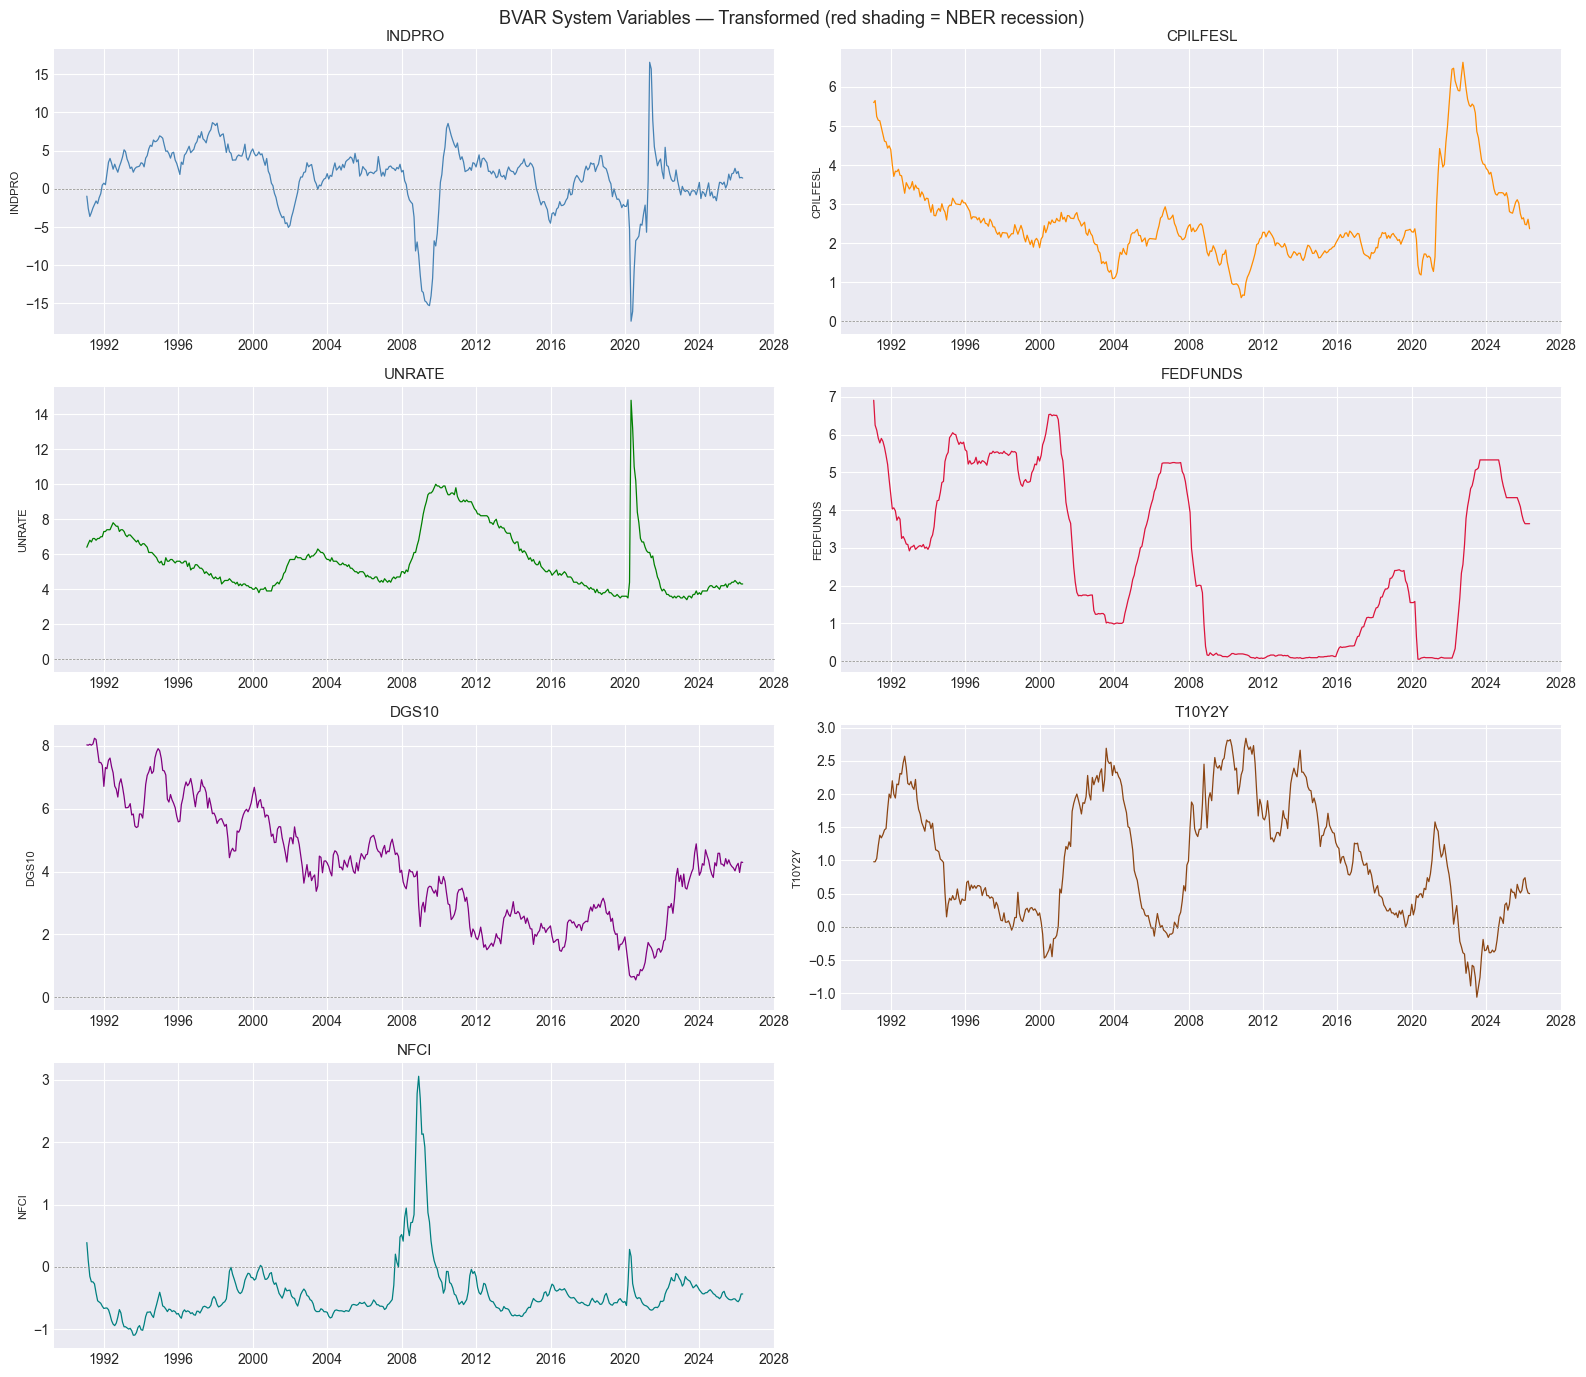

In [4]:
# ---------------------------------------------------------------------------
# Visual inspection of transformed series
# ---------------------------------------------------------------------------
# Ensure columns and labels match system order
plot_cols = list(SERIES_MAP.keys())
plot_labels = [VAR_NAMES[k] for k in SERIES_MAP]
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (col, name) in enumerate(zip(plot_cols, plot_labels)):
    ax = axes[i]
    ax.plot(df_tr.index, df_tr[col], color=COLORS[i], linewidth=0.9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(name, fontsize=11)
    ax.set_ylabel(name, fontsize=8)

# Use last subplot for recession shading reference
axes[-1].set_visible(False)

# Add NBER recession shading to all subplots
try:
    rec = df_raw["NBER Recession Indicator (Binary)"].resample("ME").last().reindex(df_tr.index, method="nearest")
    for i in range(N):
        in_rec = False
        for t in rec.index:
            if rec[t] == 1 and not in_rec:
                start = t; in_rec = True
            elif rec[t] == 0 and in_rec:
                axes[i].axvspan(start, t, alpha=0.15, color='red')
                in_rec = False
except Exception:
    pass

plt.suptitle("BVAR System Variables — Transformed (red shading = NBER recession)", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# ---------------------------------------------------------------------------
# Stationarity tests: ADF and KPSS
# Decision: stationary if ADF rejects H0 AND KPSS does not reject H0
# ---------------------------------------------------------------------------
rows = []
for col, name in zip(list(SERIES_MAP.keys()), [VAR_NAMES[k] for k in SERIES_MAP]):
    series = df_tr[col].dropna()

    adf_stat, adf_pval, _, _, adf_crit, _ = adfuller(series, autolag="AIC", regression="c")
    kpss_stat, kpss_pval, _, kpss_crit = kpss(series, regression="c", nlags="auto")

    adf_ok  = adf_pval  < 0.05   # reject H0 (unit root) → stationary signal
    kpss_ok = kpss_pval > 0.05   # fail to reject H0 (stationary) → stationary signal
    verdict = "STATIONARY" if (adf_ok and kpss_ok) else ("BORDERLINE" if (adf_ok or kpss_ok) else "NON-STATIONARY")

    rows.append({
        "Variable":   name,
        "ADF stat":   f"{adf_stat:.3f}",
        "ADF p-val":  f"{adf_pval:.3f}",
        "ADF OK":     "✓" if adf_ok else "✗",
        "KPSS stat":  f"{kpss_stat:.3f}",
        "KPSS p-val": f"{kpss_pval:.3f}",
        "KPSS OK":    "✓" if kpss_ok else "✗",
        "Verdict":    verdict,
    })
# can we print this out nicer please? maybe a markdown table or something?
df_tests = pd.DataFrame(rows).set_index("Variable")

print("Stationarity Test Results (5% significance level)")
print("ADF:  H0 = unit root.  Reject H0 (p<0.05) → stationary signal")
print("KPSS: H0 = stationary. Keep H0 (p>0.05)  → stationary signal")

display(df_tests)

_wb.write("Stationarity Tests", df_tests.reset_index())

Stationarity Test Results (5% significance level)
ADF:  H0 = unit root.  Reject H0 (p<0.05) → stationary signal
KPSS: H0 = stationary. Keep H0 (p>0.05)  → stationary signal


,ADF stat,ADF p-val,ADF OK,KPSS stat,KPSS p-val,KPSS OK,Verdict
Variable,,,,,,,
INDPRO,-3.486,0.008,✓,0.479,0.046,✗,BORDERLINE
CPILFESL,-2.825,0.055,✗,0.433,0.063,✓,BORDERLINE
UNRATE,-3.020,0.033,✓,0.330,0.100,✓,STATIONARY
FEDFUNDS,-3.143,0.024,✓,1.140,0.010,✗,BORDERLINE
DGS10,-2.298,0.173,✗,2.498,0.010,✗,NON-STATIONARY
T10Y2Y,-3.476,0.009,✓,0.364,0.093,✓,STATIONARY
NFCI,-3.730,0.004,✓,0.209,0.100,✓,STATIONARY


---
## 8. Building the VAR Design Matrix

Given $T$ observations and $p$ lags, we construct:

$$\mathbf{Y} \in \mathbb{R}^{(T-p) \times n}, \qquad \mathbf{X} \in \mathbb{R}^{(T-p) \times k}, \quad k = np + 1$$

Each row of $\mathbf{X}$ at time $t$ is:

$$\mathbf{x}_t = [\underbrace{1}_{\text{constant}},\, \underbrace{\mathbf{y}_{t-1}^T}_{n \text{ cols}},\, \underbrace{\mathbf{y}_{t-2}^T}_{n \text{ cols}},\, \ldots,\, \underbrace{\mathbf{y}_{t-p}^T}_{n \text{ cols}}]$$

The coefficient matrix $\mathbf{B}$ is organized as:

$$\mathbf{B}^T = [\underbrace{\mathbf{c}}_{n \times 1},\, \underbrace{\mathbf{A}_1}_{n \times n},\, \underbrace{\mathbf{A}_2}_{n \times n},\, \ldots,\, \underbrace{\mathbf{A}_p}_{n \times n}]$$

So row $i$ of $\mathbf{B}^T$ contains all coefficients for variable $i$'s equation.

Information Criteria by Lag Order


,AIC,BIC,T,params
p,,,,
1,130.9,357.6,423,56
2,-88.6,336.1,422,105
3,-105.2,517.4,421,154
4,-104.7,715.5,420,203
5,-83.8,933.7,419,252
6,5.5,1220.2,418,301
7,67.6,1479.2,417,350
8,152.8,1761.0,416,399



AIC-optimal lag: p = 3
BIC-optimal lag: p = 2  (BIC penalizes parameters more heavily)


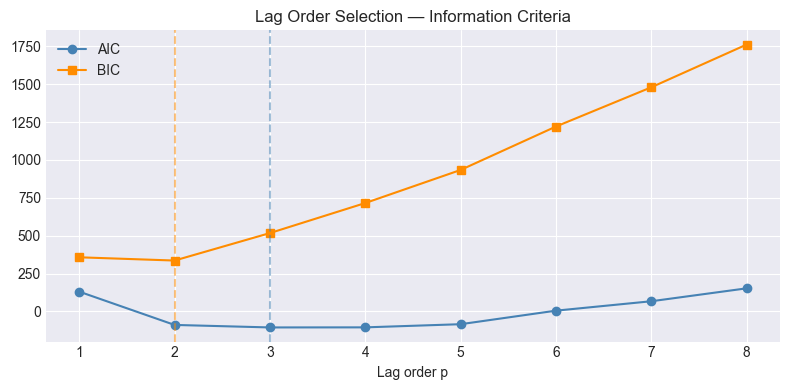

In [6]:
# ---------------------------------------------------------------------------
# Lag order selection via information criteria
# ---------------------------------------------------------------------------
def ols_var(Y, X):
    """OLS: B_hat = (X'X)^{-1} X'Y, returns (B, residuals, Sigma)"""
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    E = Y - X @ B
    T, n = Y.shape
    k = X.shape[1]
    Sigma = (E.T @ E) / (T - k)
    return B, E, Sigma

def build_XY(data, p):
    """Build (Y, X) design matrix for VAR(p)."""
    vals = data.values
    T_all, n = vals.shape
    T = T_all - p
    Y = vals[p:]
    X = np.ones((T, n * p + 1))
    for l in range(1, p + 1):
        col_start = 1 + (l - 1) * n
        X[:, col_start:col_start + n] = vals[p - l: T_all - l]
    return Y, X

def information_criteria(data, p_max=8):
    """AIC and BIC for lag selection."""
    n = data.shape[1]
    ics = []
    for p in range(1, p_max + 1):
        Y, X = build_XY(data, p)
        T = Y.shape[0]
        k = X.shape[1]
        _, _, Sigma = ols_var(Y, X)
        log_lik = -0.5 * T * n * np.log(2 * np.pi) - 0.5 * T * np.log(np.linalg.det(Sigma)) - 0.5 * T * n
        aic = -2 * log_lik + 2 * k * n
        bic = -2 * log_lik + np.log(T) * k * n
        ics.append({"p": p, "AIC": aic, "BIC": bic, "T": T, "params": k * n})
    return pd.DataFrame(ics).set_index("p")

ic_df = information_criteria(df_tr, p_max=8)
print("Information Criteria by Lag Order")
display(ic_df.round(1))

p_aic = ic_df["AIC"].idxmin()
p_bic = ic_df["BIC"].idxmin()
print(f"\nAIC-optimal lag: p = {p_aic}")
print(f"BIC-optimal lag: p = {p_bic}  (BIC penalizes parameters more heavily)")

# Plot ICs
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ic_df.index, ic_df["AIC"], 'o-', label="AIC", color="steelblue")
ax.plot(ic_df.index, ic_df["BIC"], 's-', label="BIC", color="darkorange")
ax.axvline(p_aic, color="steelblue", linestyle="--", alpha=0.5)
ax.axvline(p_bic, color="darkorange", linestyle="--", alpha=0.5)
ax.set_xlabel("Lag order p")
ax.set_title("Lag Order Selection — Information Criteria")
ax.legend()
plt.tight_layout()
plt.show()

_wb.write("Lag Selection IC", ic_df.reset_index())

In [7]:
# ---------------------------------------------------------------------------
# Set lag order and build final design matrices
# Using p=4 (common for monthly macro BVARs; balances dynamics vs. parsimony)
# ---------------------------------------------------------------------------
P = 4   # lag order — change here to experiment
N = df_tr.shape[1]
K = N * P + 1   # regressors per equation (includes constant)

Y, X = build_XY(df_tr, P)
T = Y.shape[0]

print(f"Lag order p = {P}")
print(f"Variables n = {N}")
print(f"Regressors per equation k = np + 1 = {K}")
print(f"Observations after lag adjustment T = {T}")
print(f"Total parameters in B: k × n = {K} × {N} = {K * N}")
print(f"T / k ratio = {T / K:.1f}  (>5 is comfortable; <3 needs strong priors)")
print()
print("Y shape:", Y.shape, "  (T × n)")
print("X shape:", X.shape, "  (T × k)")

Lag order p = 4
Variables n = 7
Regressors per equation k = np + 1 = 29
Observations after lag adjustment T = 420
Total parameters in B: k × n = 29 × 7 = 203
T / k ratio = 14.5  (>5 is comfortable; <3 needs strong priors)

Y shape: (420, 7)   (T × n)
X shape: (420, 29)   (T × k)


---
## 9. Minnesota Prior Calibration

### 9.1 AR(p) Residual Variances

The Minnesota prior scales cross-variable variances by the ratio $\hat{\sigma}_i^2 / \hat{\sigma}_j^2$.  
We estimate $\hat{\sigma}_i^2$ from a univariate AR($p$) on each variable separately:

$$y_{i,t} = \mu_i + \phi_{i,1} y_{i,t-1} + \cdots + \phi_{i,p} y_{i,t-p} + u_{i,t}, \quad \hat{\sigma}_i^2 = \frac{1}{T-p} \sum_t \hat{u}_{i,t}^2$$

### 9.2 Prior Mean Matrix $\mathbf{B}_0$

We encode the random-walk prior for level variables and zero-mean prior for stationary variables.

Define $\delta_i$:

$$\delta_i = \begin{cases} 1 & \text{if variable } i \text{ modeled in levels (rates, spreads, NFCI)} \\ 0 & \text{if variable } i \text{ modeled as growth rate (IP growth, Core CPI inflation)} \end{cases}$$

Then $B_0$ is $(k \times n)$ with:
- Row 0 (constant): all zeros
- Row $1 + i$ (first own lag of variable $i$): $\delta_i$ in column $i$, zeros elsewhere
- All other rows: zeros

### 9.3 Prior Variance Matrix $\mathbf{V}_0$

Diagonal with entries for coefficient $(i, j, l)$ — variable $j$, lag $l$, equation $i$:

$$v_{ij,l} = \begin{cases} \left(\dfrac{\lambda_1}{l^{\lambda_3}}\right)^2 & \text{own lag: } i = j \\[10pt] \left(\dfrac{\lambda_1\, \lambda_2}{l^{\lambda_3}}\right)^2 \dfrac{\hat{\sigma}_i^2}{\hat{\sigma}_j^2} & \text{cross lag: } i \neq j \end{cases}$$

The constant term gets a very large variance: $v_{\text{const}} = 10^4$ (diffuse — let data determine intercept).

In [8]:
# ---------------------------------------------------------------------------
# Step 1: AR(p) residual variances for each variable
# ---------------------------------------------------------------------------
ar_sigma2 = np.zeros(N)
for i in range(N):
    y_i = df_tr.iloc[:, i].values
    # Build AR(p) design matrix manually (same function)
    y_col = df_tr.iloc[:, [i]]
    Y_i, X_i = build_XY(y_col, P)
    b_i = np.linalg.lstsq(X_i, Y_i, rcond=None)[0]
    resid_i = Y_i - X_i @ b_i
    ar_sigma2[i] = (resid_i ** 2).mean()

print("AR residual std devs (sigma_i) used for Minnesota scaling:")
for i, (name, s2) in enumerate(zip(VARNAMES, ar_sigma2)):
    print(f"  {name:25s}  sigma_i = {np.sqrt(s2):.4f}")

# ---------------------------------------------------------------------------
# Minnesota hyperparameters
# ---------------------------------------------------------------------------
lambda1 = 0.2   # overall tightness
lambda2 = 0.5   # cross-variable tightness  
lambda3 = 1.0   # lag decay (linear)

# Random-walk prior: delta_i = 1 for level variables, 0 for growth rates
# Order: indpro(0), unrate(1), core_cpi(0), fedfunds(1), dgs10(1), t10y2y(1), nfci(1)
DELTA = np.array([0, 1, 0, 1, 1, 1, 1], dtype=float)

# ---------------------------------------------------------------------------
# Step 2: Build B0 (prior mean matrix) — shape (k, n)
# ---------------------------------------------------------------------------
B0 = np.zeros((K, N))
for i in range(N):
    # Row index of variable i's first own lag in X: 1 + i (lag 1 block, variable i)
    row_idx = 1 + i   # constant is row 0; lag-1 block starts at row 1
    B0[row_idx, i] = DELTA[i]

# ---------------------------------------------------------------------------
# Step 3: Build V0 (prior variance — diagonal, shape k*n stored as vector)
# ---------------------------------------------------------------------------
v0_diag = np.zeros(K * N)  # will be reshaped to (K, N) then flattened in Kronecker order

# We store V0 as a (K, N) matrix first (diagonal block structure)
V0_mat = np.zeros((K, N))

# Constant term: diffuse prior
V0_mat[0, :] = 1e4

# Lag coefficients
for l in range(1, P + 1):
    for j in range(N):                     # j = predictor variable
        row = 1 + (l - 1) * N + j          # position in X for variable j at lag l
        for i in range(N):                 # i = equation variable
            if i == j:                     # own lag
                V0_mat[row, i] = (lambda1 / l**lambda3) ** 2
            else:                          # cross lag
                V0_mat[row, i] = (lambda1 * lambda2 / l**lambda3) ** 2 * (ar_sigma2[i] / ar_sigma2[j])

# Convert to full diagonal (k × n) × (k × n) prior covariance
# Since V0 is block-diagonal (each column of B has its own diagonal prior),
# we store as a flat vector of length k*n and work with it accordingly
# For the Normal-Wishart, V0 refers to the (k × k) left scale: vec(B)|Σ ~ N(vec(B0), Σ⊗V0_left)
# Simpler: we use the single-equation interpretation where V0 is diagonal per equation.

# Build full diagonal prior covariance vector (for vectorized B)
# V0_diag[i*K + r] = variance of B[r, i]
V0_vec = V0_mat.T.flatten()   # length k*n; column-major order matches vec(B)

print(f"\nMinnesota hyperparameters:")
print(f"  lambda1 (overall tightness) = {lambda1}")
print(f"  lambda2 (cross-var tightness) = {lambda2}")
print(f"  lambda3 (lag decay) = {lambda3}")
print(f"\nPrior variance summary (diagonal of V0):")
print(f"  Constant term prior std = {np.sqrt(V0_mat[0, 0]):.0f}  (diffuse)")
print(f"  Own lag-1 prior std     = {np.sqrt(V0_mat[1, 0]):.4f}  (lambda1)")
print(f"  Own lag-4 prior std     = {np.sqrt(V0_mat[1 + 3*N, 0]):.4f}  (lambda1/4)")
print(f"  Cross lag-1 prior std   ≈ {np.sqrt(np.mean([V0_mat[1+j, i] for i in range(N) for j in range(N) if i!=j])):.4f}")

_ar_prior_df = pd.DataFrame({
    "variable":  VARNAMES,
    "delta":     DELTA,
    "ar_sigma":  np.sqrt(ar_sigma2).round(6),
    "ar_sigma2": ar_sigma2.round(8),
})
_hyper_df = pd.DataFrame([
    {"parameter": "lambda1 (overall tightness)", "value": lambda1},
    {"parameter": "lambda2 (cross-var tightness)", "value": lambda2},
    {"parameter": "lambda3 (lag decay)", "value": lambda3},
])
_wb.write("Minnesota Prior - AR Sigmas", _ar_prior_df)
_wb.write("Minnesota Prior - Hyperparams", _hyper_df)

AR residual std devs (sigma_i) used for Minnesota scaling:
  INDPRO                     sigma_i = 1.3514
  CPILFESL                   sigma_i = 0.1531
  UNRATE                     sigma_i = 0.5488
  FEDFUNDS                   sigma_i = 0.1330
  DGS10                      sigma_i = 0.2567
  T10Y2Y                     sigma_i = 0.1588
  NFCI                       sigma_i = 0.0911

Minnesota hyperparameters:
  lambda1 (overall tightness) = 0.2
  lambda2 (cross-var tightness) = 0.5
  lambda3 (lag decay) = 1.0

Prior variance summary (diagonal of V0):
  Constant term prior std = 100  (diffuse)
  Own lag-1 prior std     = 0.2000  (lambda1)
  Own lag-4 prior std     = 0.0500  (lambda1/4)
  Cross lag-1 prior std   ≈ 0.3855


---
## 10. Posterior Computation and Simulation

### 10.1 Analytical Posterior

Working equation-by-equation (treating $\hat{\sigma}_i^2$ as fixed for the prior, which is the standard Litterman approach):

For equation $i$, let $\mathbf{y}_i$ be column $i$ of $\mathbf{Y}$, and $\mathbf{b}_i$ be column $i$ of $\mathbf{B}$.  
The likelihood and prior combine to give a Gaussian posterior:

$$p(\mathbf{b}_i \mid \mathbf{Y}) \propto \mathcal{N}(\bar{\mathbf{b}}_i,\, \bar{\boldsymbol{\Omega}}_i)$$

where:

$$\bar{\boldsymbol{\Omega}}_i^{-1} = \boldsymbol{\Omega}_{0i}^{-1} + \frac{\mathbf{X}^T\mathbf{X}}{\hat{\sigma}_i^2}$$

$$\bar{\mathbf{b}}_i = \bar{\boldsymbol{\Omega}}_i \left(\boldsymbol{\Omega}_{0i}^{-1}\mathbf{b}_{0i} + \frac{\mathbf{X}^T\mathbf{y}_i}{\hat{\sigma}_i^2}\right)$$

and $\boldsymbol{\Omega}_{0i} = \text{diag}(\mathbf{V}_0[\cdot, i] \cdot \hat{\sigma}_i^2)$.

**Note on the $\hat{\sigma}_i^2$ factor:** The prior variance $\sigma^2_{ij,l}$ in the Minnesota formula already includes the $\hat{\sigma}_i^2 / \hat{\sigma}_j^2$ scaling — this accounts for different measurement units across variables.

### 10.2 Full Normal-Wishart Posterior (Joint)

For the joint posterior over all equations simultaneously:

$$\bar{\mathbf{V}} = \left(\mathbf{V}_{0,\text{left}}^{-1} + \mathbf{X}^T\mathbf{X}\right)^{-1}$$

$$\bar{\mathbf{B}} = \bar{\mathbf{V}}\left(\mathbf{V}_{0,\text{left}}^{-1}\mathbf{B}_0 + \mathbf{X}^T\mathbf{Y}\right)$$

$$\bar{\mathbf{S}} = \mathbf{S}_0 + \mathbf{Y}^T\mathbf{Y} + \mathbf{B}_0^T\mathbf{V}_{0,\text{left}}^{-1}\mathbf{B}_0 - \bar{\mathbf{B}}^T\bar{\mathbf{V}}^{-1}\bar{\mathbf{B}}$$

$$\bar{\nu} = \nu_0 + T$$

where $\mathbf{V}_{0,\text{left}} \in \mathbb{R}^{k \times k}$ is the left Kronecker factor from the Minnesota prior.

In [9]:
# ---------------------------------------------------------------------------
# Equation-by-equation posterior (Litterman / Minnesota approach)
# Treats sigma_i^2 as known (fixed at AR estimates) for the prior scaling
# ---------------------------------------------------------------------------
B_ols, E_ols, Sigma_ols = ols_var(Y, X)
sigma2_ols = np.diag(Sigma_ols)   # OLS residual variances per equation

# Posterior mean and covariance for each equation
B_post = np.zeros((K, N))       # posterior mean of B
Omega_post = np.zeros((N, K, K))  # posterior covariance per equation

XtX = X.T @ X   # (K × K) — compute once

for i in range(N):
    # Prior precision for equation i: diagonal with entries 1/V0_mat[r, i]
    # V0_mat already has sigma_i^2 baked into cross-variable entries
    v0_eq = V0_mat[:, i] * ar_sigma2[i]   # scale by sigma_i^2
    v0_eq = np.where(v0_eq < 1e-12, 1e8, v0_eq)  # avoid divide-by-zero for zeros
    Omega0i_inv = np.diag(1.0 / v0_eq)    # (K × K) prior precision

    # Posterior precision
    Omega_post_inv = Omega0i_inv + XtX / ar_sigma2[i]

    # Posterior covariance (invert via Cholesky for numerical stability)
    try:
        L_post = np.linalg.cholesky(Omega_post_inv)
        Omega_post[i] = np.linalg.inv(Omega_post_inv)
    except np.linalg.LinAlgError:
        Omega_post[i] = np.linalg.pinv(Omega_post_inv)

    # Posterior mean: Omega_post_i * (Omega0i_inv * b0i + X'y_i / sigma_i^2)
    b0i = B0[:, i]
    rhs = Omega0i_inv @ b0i + X.T @ Y[:, i] / ar_sigma2[i]
    B_post[:, i] = Omega_post[i] @ rhs

# ---------------------------------------------------------------------------
# Compare OLS vs posterior mean
# ---------------------------------------------------------------------------
print("Comparison: OLS vs BVAR Posterior Mean Coefficients")
print("(Showing lag-1 block only — n×n matrix of first-lag effects)")
print()

def extract_lag(B, lag, n):
    """Extract the A_l matrix from B (lag l, 1-indexed)."""
    row_start = 1 + (lag - 1) * n
    return B[row_start:row_start + n, :].T  # (n × n)

A1_ols  = extract_lag(B_ols, 1, N)
A1_post = extract_lag(B_post, 1, N)

short_names = ["IPg", "UNRT", "CPI", "FFR", "10Y", "Sprd", "NFCI"]

print("A1_OLS (rows=equation, cols=predictor):")
print(pd.DataFrame(A1_ols.round(3), index=short_names, columns=short_names).to_string())
print()
print("A1_BVAR (posterior mean — notice shrinkage toward diagonal):")
print(pd.DataFrame(A1_post.round(3), index=short_names, columns=short_names).to_string())

_a1_ols_df  = pd.DataFrame(A1_ols.round(6),  index=short_names, columns=short_names)
_a1_post_df = pd.DataFrame(A1_post.round(6), index=short_names, columns=short_names)
_a1_ols_df.index.name  = "equation"
_a1_post_df.index.name = "equation"
_wb.write("A1 Coefficients - OLS",         _a1_ols_df.reset_index())
_wb.write("A1 Coefficients - BVAR Posterior", _a1_post_df.reset_index())

Comparison: OLS vs BVAR Posterior Mean Coefficients
(Showing lag-1 block only — n×n matrix of first-lag effects)

A1_OLS (rows=equation, cols=predictor):
        IPg   UNRT    CPI    FFR    10Y   Sprd   NFCI
IPg   1.099  0.689  0.118  1.777  0.936 -0.283 -0.841
UNRT  0.017  1.314  0.021  0.067 -0.002  0.118 -0.169
CPI  -0.041 -0.324  0.891 -1.438 -0.106 -0.042  0.767
FFR   0.007 -0.033  0.002  1.022  0.125 -0.277 -0.367
10Y   0.000 -0.049  0.010  0.073  1.064 -0.129 -0.182
Sprd -0.011 -0.086  0.017  0.010 -0.079  1.068  0.056
NFCI -0.001  0.028 -0.004  0.151  0.002  0.097  1.728

A1_BVAR (posterior mean — notice shrinkage toward diagonal):
        IPg   UNRT    CPI    FFR    10Y   Sprd   NFCI
IPg   1.012  0.169  0.091  1.054  0.625 -0.084 -0.976
UNRT  0.003  1.029 -0.002 -0.003 -0.000 -0.003 -0.021
CPI  -0.015 -0.103  0.774 -0.248 -0.046  0.107  0.426
FFR   0.002  0.010  0.000  1.042  0.025 -0.054 -0.037
10Y  -0.002  0.005  0.002  0.005  0.996 -0.024 -0.067
Sprd -0.003 -0.012  0.004  0

In [10]:
# ---------------------------------------------------------------------------
# Posterior simulation: draw S independent parameter samples
# For each draw s:
#   B^(s)_i ~ N(B_post_i, Omega_post_i)  for each equation i
#   Sigma^(s) approximated by OLS Sigma (or drawn from IW)
# ---------------------------------------------------------------------------
S_DRAWS = 2000   # number of posterior draws
BURN_IN = 500    # discard first BURN_IN (not needed for conjugate, but good practice)

# Storage: B_draws[s] is (K × N), Sigma_draws[s] is (N × N)
B_draws     = np.zeros((S_DRAWS, K, N))
Sigma_draws = np.zeros((S_DRAWS, N, N))

# Set up IW for Sigma: nu0 = n + 2 (minimally informative), S0 = diag of OLS
nu0 = N + 2
S0  = nu0 * np.diag(ar_sigma2)  # prior mean = diag(sigma_i^2)

# OLS residuals for posterior S
E_bvar = Y - X @ B_post
S_bar  = S0 + E_bvar.T @ E_bvar   # approximate posterior scale
nu_bar = nu0 + T

# Cholesky factors for B draws
L_post_list = []
for i in range(N):
    try:
        L_post_list.append(np.linalg.cholesky(Omega_post[i]))
    except np.linalg.LinAlgError:
        # Fall back to eigenvalue decomposition if not PD
        eigvals, eigvecs = np.linalg.eigh(Omega_post[i])
        eigvals = np.maximum(eigvals, 1e-12)
        L_post_list.append(eigvecs @ np.diag(np.sqrt(eigvals)))

for s in range(S_DRAWS):
    # Draw Sigma from IW(S_bar, nu_bar)
    Sigma_draws[s] = stats.invwishart.rvs(df=nu_bar, scale=S_bar)

    # Draw each equation's coefficients
    for i in range(N):
        z = np.random.standard_normal(K)
        B_draws[s, :, i] = B_post[:, i] + L_post_list[i] @ z

# Discard burn-in
B_draws     = B_draws[BURN_IN:]
Sigma_draws = Sigma_draws[BURN_IN:]
S_EFF = len(B_draws)

print(f"Posterior draws: {S_EFF} effective samples (after {BURN_IN} burn-in)")

# Posterior uncertainty summary for key coefficients
print("\nPosterior uncertainty: Fed Funds Rate equation (A1 row)")
ffr_idx = list(SERIES_MAP.keys()).index('fedfunds')
A1_draws = B_draws[:, 1:1+N, ffr_idx]   # lag-1 block, FFR equation
ci_df = pd.DataFrame({
    "Mean":  A1_draws.mean(0),
    "Std":   A1_draws.std(0),
    "5th%":  np.percentile(A1_draws, 5, axis=0),
    "95th%": np.percentile(A1_draws, 95, axis=0),
}, index=short_names)
display(ci_df.round(4))

_wb.write("Posterior Uncertainty - FFR Eq", ci_df.reset_index().rename(columns={"index": "predictor"}))
_regressor_names = ["const"] + [f"{n}_lag{l}" for l in range(1, P+1) for n in short_names]
_bpost_df = pd.DataFrame(B_post.round(6), columns=short_names)
_bpost_df.insert(0, "regressor", _regressor_names)
_wb.write("Posterior Mean B", _bpost_df)

Posterior draws: 1500 effective samples (after 500 burn-in)

Posterior uncertainty: Fed Funds Rate equation (A1 row)


,Mean,Std,5th%,95th%
IPg,0.0025,0.0011,0.0007,0.0043
UNRT,0.0100,0.0076,-0.0025,0.0224
CPI,0.0004,0.0027,-0.0040,0.0050
FFR,1.0421,0.0141,1.0199,1.0654
10Y,0.0248,0.0054,0.0159,0.0336
Sprd,-0.0538,0.0088,-0.0677,-0.0393
NFCI,-0.0381,0.0132,-0.0601,-0.0165


---
## 11. Impulse Response Functions (IRFs)

### 11.1 MA($\infty$) Representation

Any stable VAR(p) has a Wold/MA($\infty$) representation:

$$\mathbf{y}_t = \boldsymbol{\mu} + \sum_{h=0}^{\infty} \mathbf{\Phi}_h \boldsymbol{\varepsilon}_{t-h}$$

where $\mathbf{\Phi}_h \in \mathbb{R}^{n \times n}$ is the matrix of MA coefficients at horizon $h$.  
The $(i,j)$ element $\Phi_h(i,j)$ measures the response of variable $i$ at horizon $h$ to a unit reduced-form shock in variable $j$ at $t=0$.

### 11.2 Recursion for $\mathbf{\Phi}_h$

$$\mathbf{\Phi}_0 = \mathbf{I}_n$$

$$\mathbf{\Phi}_h = \sum_{l=1}^{\min(h,p)} \mathbf{A}_l\, \mathbf{\Phi}_{h-l}, \qquad h = 1, 2, 3, \ldots$$

This is a vector autoregressive recursion — each $\mathbf{\Phi}_h$ is a weighted sum of the previous responses via the autoregressive structure.

### 11.3 Structural Identification — Cholesky Decomposition

The reduced-form shocks $\boldsymbol{\varepsilon}_t$ are correlated (off-diagonal $\boldsymbol{\Sigma}$).  
To identify **structural shocks** $\mathbf{u}_t$ with $\text{Cov}(\mathbf{u}_t) = \mathbf{I}_n$, we decompose:

$$\boldsymbol{\Sigma} = \mathbf{P}\mathbf{P}^T \quad (\text{Cholesky: } \mathbf{P} \text{ lower triangular})$$

$$\boldsymbol{\varepsilon}_t = \mathbf{P}\, \mathbf{u}_t, \quad \mathbf{u}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_n)$$

The **structural IRF** (SIRF) at horizon $h$:

$$\mathbf{\Theta}_h = \mathbf{\Phi}_h\, \mathbf{P}$$

$\Theta_h(i,j)$ = response of variable $i$ at horizon $h$ to a one-standard-deviation structural shock in variable $j$.

### 11.4 The Cholesky Ordering and Its Meaning

**Cholesky identification is recursive:** variable $j$ at position $j$ in the ordering is assumed to respond **instantaneously** to shocks from variables $1, \ldots, j-1$ but **not** to variables $j+1, \ldots, n$ within the same period.

Our ordering (slow → fast):
1. **IP Growth** — real activity, quarterly-ish dynamics, last to respond within a month
2. **Unemployment** — labor market, slow adjustments
3. **Core CPI** — inflation, sticky prices
4. **Fed Funds** — policy rate, reacts to 1–3 but not contemporaneously to financial markets
5. **10Y Treasury** — long rate, reacts to policy signals
6. **10Y-2Y Spread** — driven by 4 and 5
7. **NFCI** — financial conditions, absorbs everything instantly

A **monetary policy shock** is a surprise move in Fed Funds not explained by contemporaneous IP, unemployment, or inflation — exactly what Cholesky ordering identifies.

### 11.5 Bayesian Confidence Bands

For each posterior draw $(\mathbf{B}^{(s)}, \boldsymbol{\Sigma}^{(s)})$, compute $\mathbf{\Theta}_h^{(s)}$.  
The 16th/84th percentile bands (±1 posterior std) form Bayesian credible intervals for each IRF.

In [11]:
# ---------------------------------------------------------------------------
# Compute IRFs for each posterior draw
# ---------------------------------------------------------------------------
H = 48   # horizon in months (4 years)

def compute_phi(B, n, p, H):
    """Compute reduced-form MA coefficients Phi_0,...,Phi_H via recursion.
    B: (k × n) coefficient matrix (rows: const, then lag blocks)
    Returns: (H+1, n, n) array
    """
    # Extract A_l matrices
    A = []
    for l in range(1, p + 1):
        A.append(B[1 + (l-1)*n : 1 + l*n, :].T)   # (n × n)

    Phi = np.zeros((H + 1, n, n))
    Phi[0] = np.eye(n)
    for h in range(1, H + 1):
        for l in range(1, min(h, p) + 1):
            Phi[h] += A[l-1] @ Phi[h - l]
    return Phi

def is_stable(B, n, p):
    """Check VAR stability: all eigenvalues of companion matrix inside unit circle."""
    F = np.zeros((n * p, n * p))
    for l in range(1, p + 1):
        F[:n, (l-1)*n:l*n] = B[1 + (l-1)*n : 1 + l*n, :].T
    if p > 1:
        F[n:, :n*(p-1)] = np.eye(n * (p - 1))
    return np.max(np.abs(np.linalg.eigvals(F))) < 1.0

# Compute IRFs for all stable draws
SIRF_draws = np.zeros((S_EFF, H + 1, N, N))
n_stable = 0

for s in range(S_EFF):
    if not is_stable(B_draws[s], N, P):
        continue
    Phi_s = compute_phi(B_draws[s], N, P, H)
    P_chol = np.linalg.cholesky(Sigma_draws[s])   # lower triangular Cholesky
    for h in range(H + 1):
        SIRF_draws[s, h] = Phi_s[h] @ P_chol      # Theta_h = Phi_h * P
    n_stable += 1

# Also compute point-estimate IRF from posterior mean
Phi_mean = compute_phi(B_post, N, P, H)
P_mean   = np.linalg.cholesky(Sigma_ols)
SIRF_mean = np.array([Phi_mean[h] @ P_mean for h in range(H + 1)])

print(f"Stable draws: {n_stable} / {S_EFF} ({100*n_stable/S_EFF:.1f}%)")
if n_stable < S_EFF * 0.5:
    print("WARNING: Many unstable draws — consider tightening lambda1 or reducing p")



Stable draws: 1344 / 1500 (89.6%)


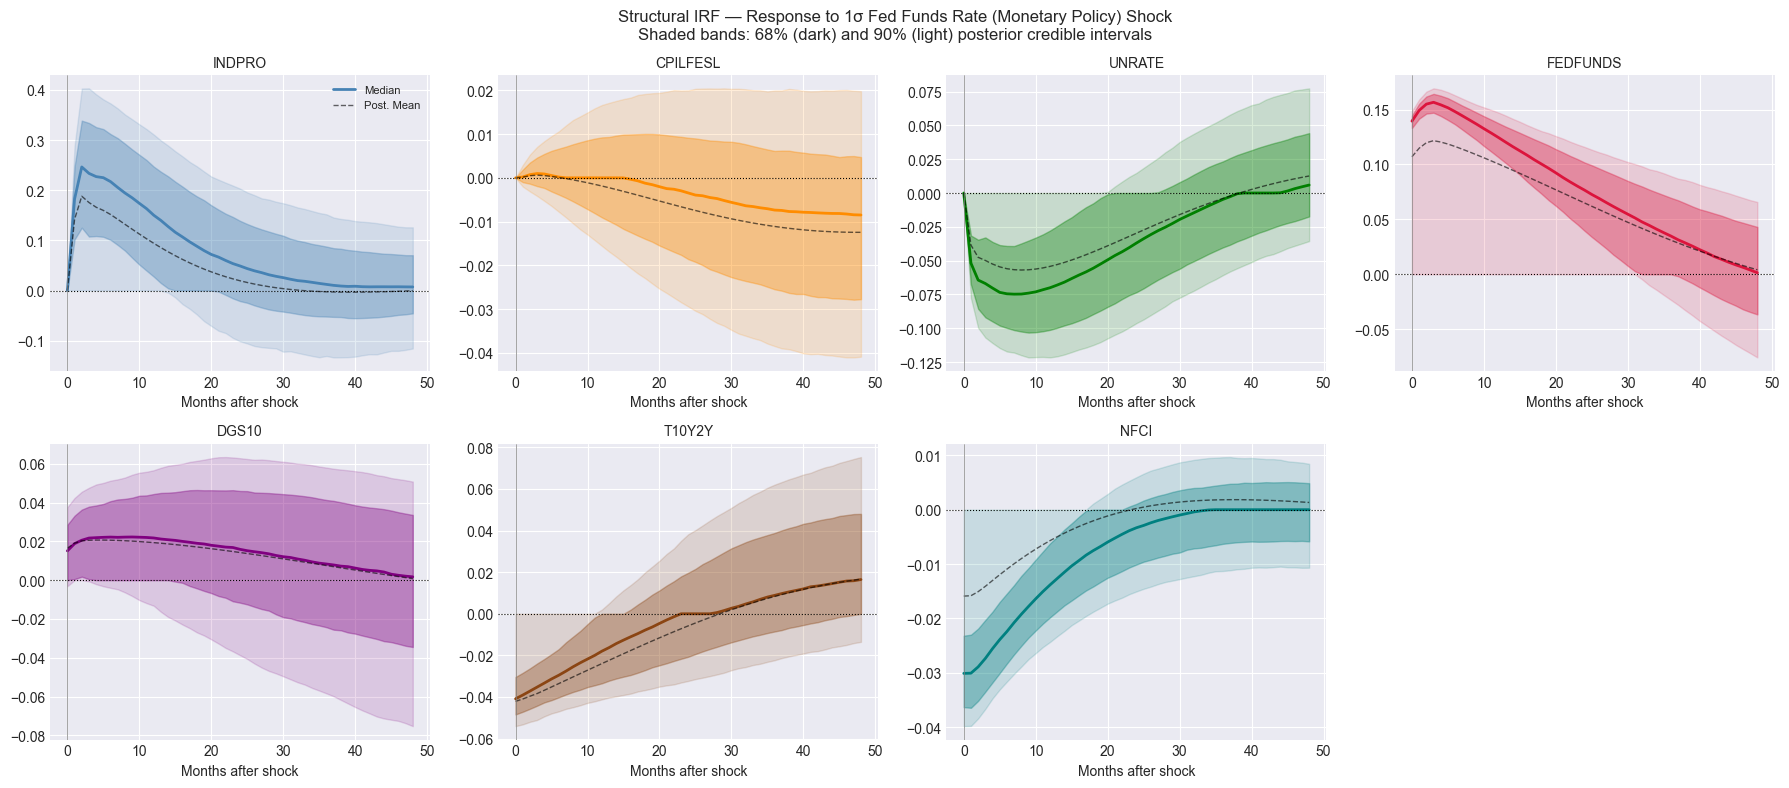

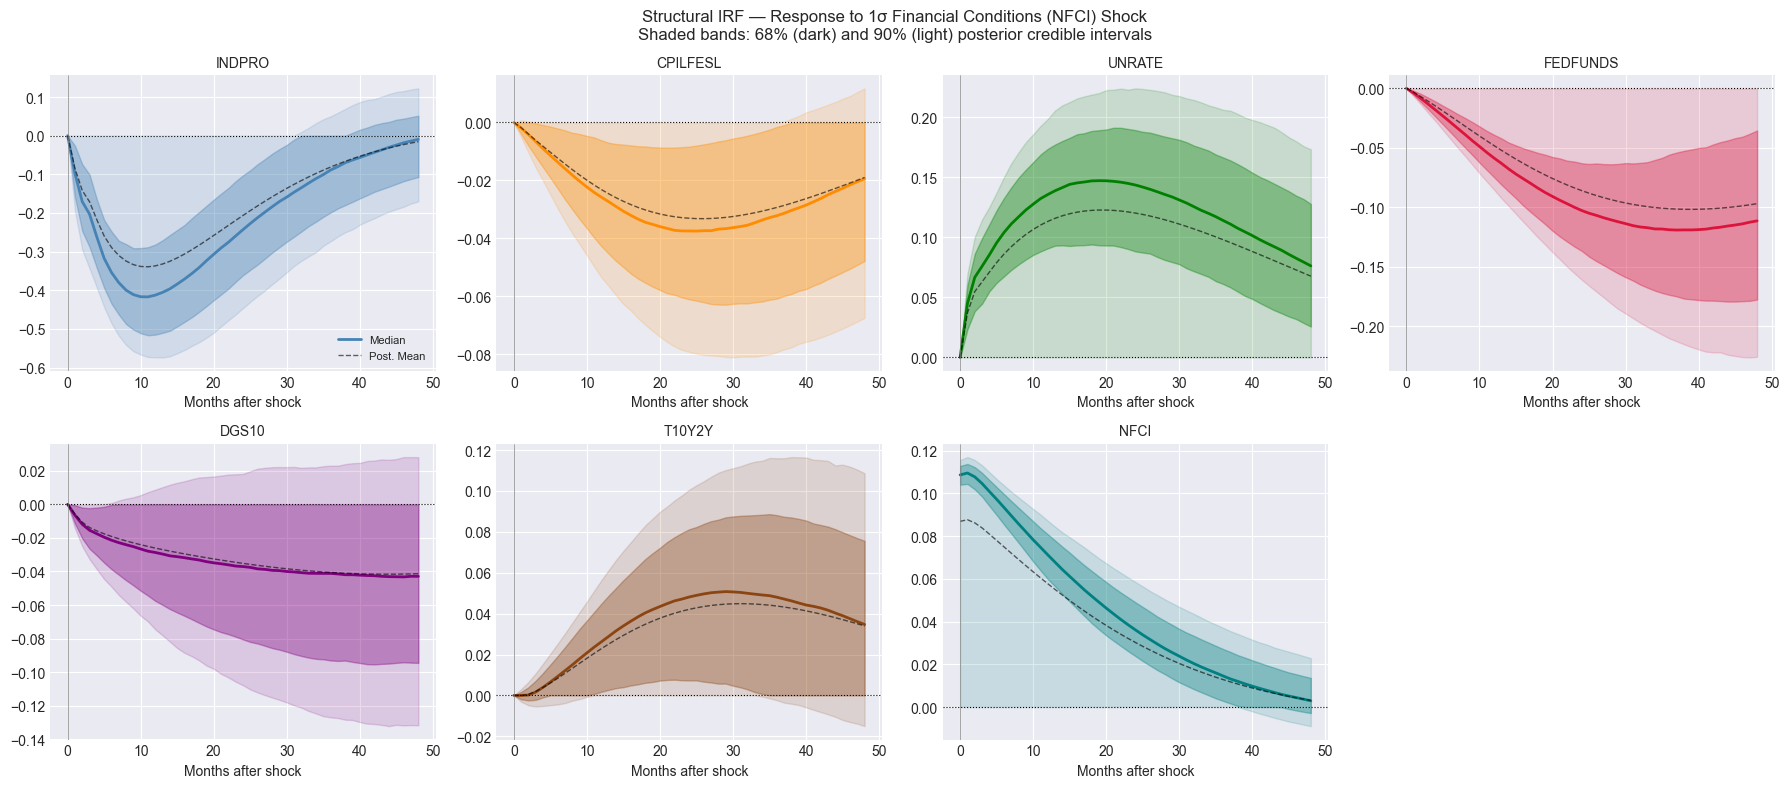

In [12]:
# ---------------------------------------------------------------------------
# Plot IRFs: one shock at a time
# We focus on the monetary policy shock (Fed Funds, column ffr_idx)
# and the financial conditions shock (NFCI, column nfci_idx)
# ---------------------------------------------------------------------------
nfci_idx = list(SERIES_MAP.keys()).index('nfci')
horizons = np.arange(H + 1)

def plot_irf_shock(shock_idx, shock_name, n_stable):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    
    valid_draws = SIRF_draws[SIRF_draws[:, 0, 0, 0] != 0]   # non-zero rows

    for i in range(N):
        ax = axes[i]
        
        # Posterior credible intervals
        irf_i_draws = SIRF_draws[:n_stable, :, i, shock_idx]   # (S × H+1)
        med  = np.median(irf_i_draws, axis=0)
        lo16 = np.percentile(irf_i_draws, 16, axis=0)
        hi84 = np.percentile(irf_i_draws, 84, axis=0)
        lo05 = np.percentile(irf_i_draws, 5,  axis=0)
        hi95 = np.percentile(irf_i_draws, 95, axis=0)
        
        ax.fill_between(horizons, lo05, hi95, alpha=0.15, color=COLORS[i])
        ax.fill_between(horizons, lo16, hi84, alpha=0.35, color=COLORS[i])
        ax.plot(horizons, med, color=COLORS[i], linewidth=2, label='Median')
        ax.plot(horizons, SIRF_mean[:, i, shock_idx], 'k--', linewidth=1, alpha=0.6, label='Post. Mean')
        ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
        ax.axvline(0, color='gray',  linewidth=0.5)
        
        ax.set_title(VARNAMES[i], fontsize=10)
        ax.set_xlabel('Months after shock')
        if i == 0:
            ax.legend(fontsize=8)

    axes[-1].set_visible(False)
    plt.suptitle(f'Structural IRF — Response to 1σ {shock_name} Shock\n'
                 f'Shaded bands: 68% (dark) and 90% (light) posterior credible intervals',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

# Monetary policy shock
plot_irf_shock(ffr_idx, "Fed Funds Rate (Monetary Policy)", n_stable)

# Financial conditions shock
plot_irf_shock(nfci_idx, "Financial Conditions (NFCI)", n_stable)

# Excel export — IRF sheets
_nfci_idx = list(SERIES_MAP.keys()).index("nfci")
_ffr_idx  = list(SERIES_MAP.keys()).index("fedfunds")
for _si, _sname in [(_ffr_idx, "IRF - FFR Shock"), (_nfci_idx, "IRF - NFCI Shock")]:
    _irf_df = pd.DataFrame(SIRF_mean[:, :, _si].round(6), columns=short_names)
    _irf_df.insert(0, "horizon_months", np.arange(H + 1))
    _wb.write(_sname, _irf_df)


---
## 12. Forecast Error Variance Decomposition (FEVD)

### 12.1 Forecast Errors and Their Sources

The $h$-step ahead forecast error is:

$$\mathbf{y}_{t+h} - \hat{\mathbf{y}}_{t+h|t} = \sum_{k=0}^{h-1} \mathbf{\Phi}_k\, \boldsymbol{\varepsilon}_{t+h-k} = \sum_{k=0}^{h-1} \mathbf{\Theta}_k\, \mathbf{u}_{t+h-k}$$

The forecast error variance for variable $i$ at horizon $h$ is:

$$\text{MSE}_i(h) = \sum_{k=0}^{h-1} \sum_{j=1}^{n} \left[\mathbf{\Theta}_k\right]_{ij}^2$$

### 12.2 FEVD Formula

The **fraction** of variable $i$'s $h$-step forecast error variance attributable to structural shock $j$:

$$\text{FEVD}_{ij}(h) = \frac{\displaystyle\sum_{k=0}^{h-1} \left[\mathbf{\Theta}_k\right]_{ij}^2}{\displaystyle\sum_{m=1}^{n}\sum_{k=0}^{h-1} \left[\mathbf{\Theta}_k\right]_{im}^2}$$

By construction: $\sum_{j=1}^{n} \text{FEVD}_{ij}(h) = 1$ for all $i, h$.

**Economic interpretation:**  
- High $\text{FEVD}_{ij}(h)$ at short horizons → variable $j$ is a contemporaneous driver of variable $i$
- High $\text{FEVD}_{ij}(h)$ at long horizons → variable $j$ is a fundamental driver of long-run dynamics in $i$
- Variables that explain only their own variance → nearly exogenous to the system

In [13]:
# ---------------------------------------------------------------------------
# Compute FEVD from posterior mean IRFs
# FEVD[i, j, h] = fraction of variable i's h-step variance from shock j
# ---------------------------------------------------------------------------
def compute_fevd(SIRF, H):
    """Compute FEVD from structural IRF (H+1, n, n)."""
    n = SIRF.shape[1]
    fevd = np.zeros((n, n, H + 1))
    for h in range(1, H + 1):
        # Cumulative squared IRF up to h-1
        cum_sq = (SIRF[:h] ** 2).sum(axis=0)   # (n × n)
        totals = cum_sq.sum(axis=1, keepdims=True)   # (n × 1)
        totals = np.where(totals < 1e-12, 1.0, totals)
        fevd[:, :, h] = cum_sq / totals
    fevd[:, :, 0] = np.eye(n) / n   # horizon 0 undefined, set uniform
    return fevd

FEVD = compute_fevd(SIRF_mean, H)

# Print FEVD at key horizons: 1, 6, 12, 24, 48 months
for h in [1, 6, 12, 24, 48]:
    print(f"\nFEVD at horizon h={h} months (rows=variable, cols=shock source):")
    df_fevd = pd.DataFrame(
        (FEVD[:, :, h] * 100).round(1),
        index=short_names,
        columns=short_names
    )
    display(df_fevd)

for _h in [1, 6, 12, 24, 48]:
    _fevd_df = pd.DataFrame((FEVD[:, :, _h] * 100).round(2),
                            index=short_names, columns=short_names)
    _fevd_df.index.name = "variable"
    _wb.write(f"FEVD h={_h}mo", _fevd_df.reset_index())


FEVD at horizon h=1 months (rows=variable, cols=shock source):


,IPg,UNRT,CPI,FFR,10Y,Sprd,NFCI
IPg,100.0,0.0,0.0,0.0,0.0,0.0,0.0
UNRT,12.1,87.9,0.0,0.0,0.0,0.0,0.0
CPI,13.4,0.2,86.4,0.0,0.0,0.0,0.0
FFR,0.4,0.3,0.6,98.6,0.0,0.0,0.0
10Y,0.0,0.0,0.0,0.4,99.6,0.0,0.0
Sprd,0.0,0.0,0.2,7.7,12.0,80.0,0.0
NFCI,0.0,0.0,2.5,3.1,1.0,0.7,92.7



FEVD at horizon h=6 months (rows=variable, cols=shock source):


,IPg,UNRT,CPI,FFR,10Y,Sprd,NFCI
IPg,86.2,0.7,2.9,2.4,4.9,0.0,2.9
UNRT,15.2,84.6,0.0,0.0,0.0,0.0,0.2
CPI,17.3,0.7,76.5,1.6,0.1,1.3,2.6
FFR,2.3,0.9,0.2,89.1,1.6,5.0,0.8
10Y,0.0,0.0,0.1,0.6,98.8,0.1,0.2
Sprd,1.0,0.2,0.1,6.8,7.9,84.0,0.0
NFCI,0.4,0.0,3.6,2.7,1.0,0.7,91.6



FEVD at horizon h=12 months (rows=variable, cols=shock source):


,IPg,UNRT,CPI,FFR,10Y,Sprd,NFCI
IPg,69.6,1.4,9.0,3.1,6.4,0.1,10.3
UNRT,17.0,82.1,0.0,0.0,0.0,0.1,0.8
CPI,17.8,0.8,65.1,2.9,0.1,5.9,7.4
FFR,4.2,2.0,0.3,66.4,6.2,17.5,3.4
10Y,0.0,0.3,0.2,0.7,97.7,0.5,0.6
Sprd,2.6,0.5,0.1,5.4,4.7,86.2,0.5
NFCI,1.2,0.0,4.4,2.2,1.1,0.6,90.5



FEVD at horizon h=24 months (rows=variable, cols=shock source):


,IPg,UNRT,CPI,FFR,10Y,Sprd,NFCI
IPg,55.0,1.9,14.0,2.8,8.0,0.2,18.1
UNRT,17.6,79.0,0.2,0.1,0.1,0.2,2.8
CPI,15.0,0.9,46.8,3.6,0.2,17.0,16.5
FFR,4.7,3.7,1.2,33.9,13.3,34.3,8.9
10Y,0.0,1.5,0.3,0.8,94.4,1.6,1.4
Sprd,3.8,1.0,0.4,3.4,2.6,85.8,3.0
NFCI,2.5,0.1,4.9,1.7,1.2,0.5,89.0



FEVD at horizon h=48 months (rows=variable, cols=shock source):


,IPg,UNRT,CPI,FFR,10Y,Sprd,NFCI
IPg,50.9,2.0,14.0,2.5,10.2,1.4,18.9
UNRT,16.3,75.5,0.4,0.5,1.2,0.6,5.5
CPI,11.5,1.0,35.4,2.9,0.2,25.3,23.7
FFR,3.7,6.2,2.2,14.4,18.1,40.1,15.2
10Y,0.3,4.6,0.5,0.6,87.0,3.6,3.3
Sprd,3.5,1.7,1.0,2.5,2.5,81.3,7.4
NFCI,3.8,0.2,4.8,1.6,1.2,3.0,85.6


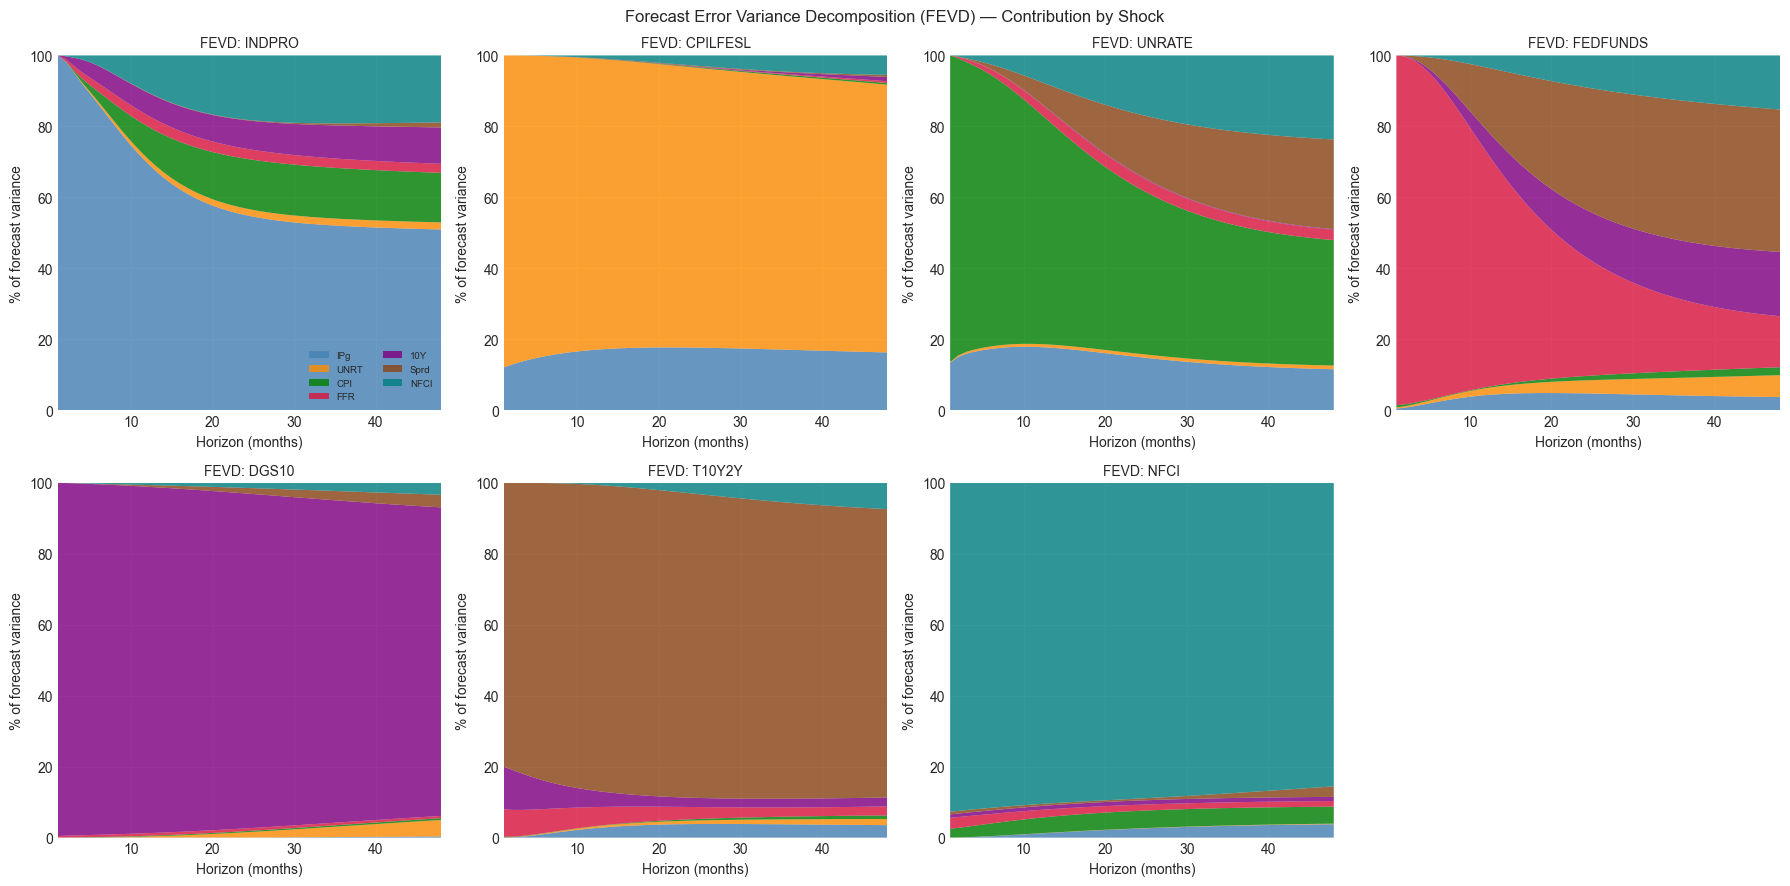

In [14]:
# ---------------------------------------------------------------------------
# FEVD stacked area charts — one per variable
# Shows how contribution of each shock evolves over the forecast horizon
# ---------------------------------------------------------------------------
PLOT_HORIZONS = np.arange(1, H + 1)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i in range(N):
    ax = axes[i]
    data_stack = FEVD[i, :, 1:] * 100   # (n × H) percentages
    ax.stackplot(
        PLOT_HORIZONS,
        data_stack,
        labels=short_names,
        colors=COLORS,
        alpha=0.8
    )
    ax.set_xlim(1, H)
    ax.set_ylim(0, 100)
    ax.set_title(f"FEVD: {VARNAMES[i]}", fontsize=10)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("% of forecast variance")
    if i == 0:
        ax.legend(fontsize=7, loc='lower right', ncol=2)

axes[-1].set_visible(False)
plt.suptitle("Forecast Error Variance Decomposition (FEVD) — Contribution by Shock", fontsize=12)
plt.tight_layout()
plt.show()

---
## 13. Probabilistic Forecasting

### 13.1 VAR Forecast Formula

The $h$-step ahead conditional mean forecast from the VAR:

$$\hat{\mathbf{y}}_{T+h|T} = \mathbf{c} + \sum_{l=1}^{p} \mathbf{A}_l\, \hat{\mathbf{y}}_{T+h-l|T}$$

where $\hat{\mathbf{y}}_{T+j|T} = \mathbf{y}_{T+j}$ for $j \leq 0$ (known past values).

This is simply iterated one-step-ahead predictions.

### 13.2 Bayesian Forecast Distribution

For each posterior draw $(\mathbf{B}^{(s)}, \boldsymbol{\Sigma}^{(s)})$, we simulate a forecast path by:

1. Starting from observed $\mathbf{y}_T, \mathbf{y}_{T-1}, \ldots, \mathbf{y}_{T-p+1}$
2. Drawing innovations $\boldsymbol{\varepsilon}_{T+h}^{(s)} \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma}^{(s)})$ at each step
3. Iterating forward:

$$\mathbf{y}_{T+h}^{(s)} = \mathbf{c}^{(s)} + \sum_{l=1}^{p} \mathbf{A}_l^{(s)}\, \mathbf{y}_{T+h-l}^{(s)} + \boldsymbol{\varepsilon}_{T+h}^{(s)}$$

The **forecast predictive distribution** integrates over both:
- **Parameter uncertainty:** different draws of $(\mathbf{B}^{(s)}, \boldsymbol{\Sigma}^{(s)})$
- **Shock uncertainty:** different realizations of $\boldsymbol{\varepsilon}_{T+h}^{(s)}$

This is a proper Bayesian predictive distribution — no classical BVAR will give you this without full posterior simulation.

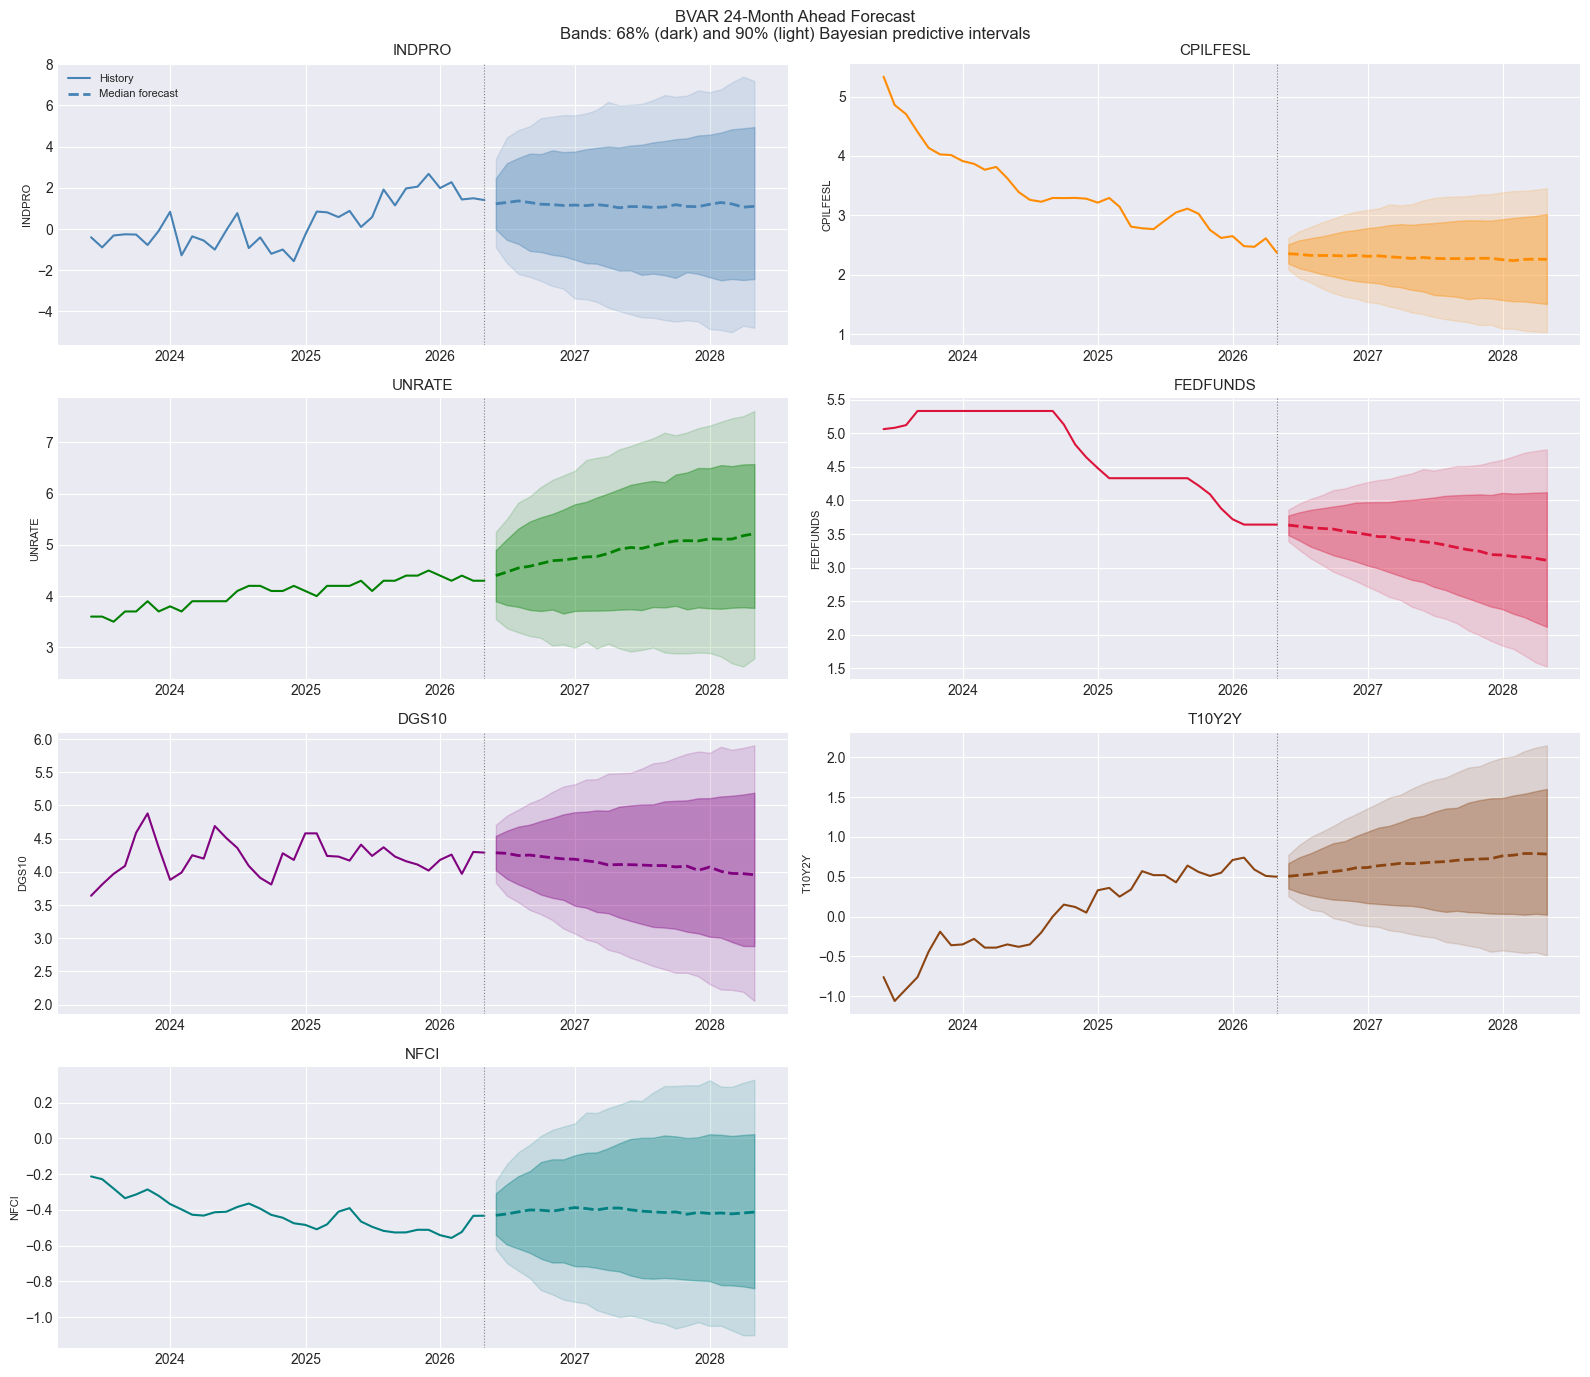


Posterior Median Forecast Summary:


,IPg,UNRT,CPI,FFR,10Y,Sprd,NFCI
Horizon,,,,,,,
+1mo (2026-05),1.23,2.35,4.40,3.63,4.29,0.51,-0.43
+3mo (2026-07),1.37,2.32,4.55,3.59,4.25,0.53,-0.41
+6mo (2026-10),1.19,2.31,4.69,3.54,4.21,0.58,-0.41
+12mo (2027-04),1.03,2.27,4.91,3.41,4.11,0.66,-0.39
+18mo (2027-10),1.10,2.28,5.08,3.24,4.09,0.72,-0.42
+24mo (2028-04),1.10,2.26,5.22,3.11,3.96,0.78,-0.41


In [15]:
# ---------------------------------------------------------------------------
# Probabilistic forecast: 24 months ahead
# ---------------------------------------------------------------------------
H_FORE = 24   # forecast horizon
N_PATH = 1000  # number of simulated paths per draw

# Starting conditions: last P observations
last_obs = df_tr.values[-P:]   # (p × n)

# Storage: forecast_draws[s, h, i]
forecast_draws = np.zeros((S_EFF, H_FORE, N))

for s in range(S_EFF):
    B_s     = B_draws[s]        # (k × n)
    Sigma_s = Sigma_draws[s]    # (n × n)
    const_s = B_s[0]            # (n,)

    # Cholesky of Sigma for drawing shocks
    try:
        L_s = np.linalg.cholesky(Sigma_s)
    except np.linalg.LinAlgError:
        L_s = np.linalg.cholesky(Sigma_s + 1e-8 * np.eye(N))

    # Initialize path history with known past
    history = list(last_obs.copy())   # list of (n,) arrays, length p initially

    for h in range(H_FORE):
        # One-step-ahead prediction + shock
        y_next = const_s.copy()
        for l in range(1, P + 1):
            A_l = B_s[1 + (l-1)*N : 1 + l*N, :].T   # (n × n)
            y_next += A_l @ history[-(l)]              # history[-1] = most recent
        shock = L_s @ np.random.standard_normal(N)
        y_next += shock
        history.append(y_next)
        forecast_draws[s, h] = y_next

# ---------------------------------------------------------------------------
# Plot forecasts: history + predictive distribution
# ---------------------------------------------------------------------------
H_BACK = 36  # months of history to show
history_dates = df_tr.index[-H_BACK:]
history_vals  = df_tr.values[-H_BACK:]

# Forecast dates
last_date = df_tr.index[-1]
fore_dates = pd.date_range(last_date, periods=H_FORE + 1, freq='ME')[1:]

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i in range(N):
    ax = axes[i]

    # Historical
    ax.plot(history_dates, history_vals[:, i], color=COLORS[i], linewidth=1.5, label='History')

    # Forecast distribution
    fc = forecast_draws[:, :, i]   # (S × H_FORE)
    med  = np.median(fc, axis=0)
    lo16 = np.percentile(fc, 16, axis=0)
    hi84 = np.percentile(fc, 84, axis=0)
    lo05 = np.percentile(fc, 5,  axis=0)
    hi95 = np.percentile(fc, 95, axis=0)

    ax.fill_between(fore_dates, lo05, hi95, alpha=0.15, color=COLORS[i])
    ax.fill_between(fore_dates, lo16, hi84, alpha=0.35, color=COLORS[i])
    ax.plot(fore_dates, med, color=COLORS[i], linewidth=2, linestyle='--', label='Median forecast')

    # Point forecast (posterior mean B, no shocks)
    ax.axvline(last_date, color='gray', linewidth=0.8, linestyle=':')

    ax.set_title(VARNAMES[i], fontsize=11)
    ax.set_ylabel(VARNAMES[i], fontsize=8)
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle(f"BVAR 24-Month Ahead Forecast\nBands: 68% (dark) and 90% (light) Bayesian predictive intervals",
             fontsize=12)
plt.tight_layout()
plt.show()

# Print point forecast table
print("\nPosterior Median Forecast Summary:")
fore_med = np.median(forecast_draws, axis=0)   # (H_FORE × N)
rows_fore = []
for h in [1, 3, 6, 12, 18, 24]:
    row = {"Horizon": f"+{h}mo ({fore_dates[h-1].strftime('%Y-%m')})"}
    for i, name in enumerate(short_names):
        row[name] = f"{fore_med[h-1, i]:.2f}"
    rows_fore.append(row)

display(pd.DataFrame(rows_fore).set_index("Horizon"))

_fore_med  = np.median(forecast_draws, axis=0)
_fore_p5   = np.percentile(forecast_draws,  5, axis=0)
_fore_p16  = np.percentile(forecast_draws, 16, axis=0)
_fore_p84  = np.percentile(forecast_draws, 84, axis=0)
_fore_p95  = np.percentile(forecast_draws, 95, axis=0)
_fore_path_df = pd.DataFrame({"date": fore_dates})
for _i, _n in enumerate(short_names):
    _fore_path_df[f"{_n}_median"] = _fore_med[:, _i].round(4)
    _fore_path_df[f"{_n}_p5"]     = _fore_p5[:,  _i].round(4)
    _fore_path_df[f"{_n}_p16"]    = _fore_p16[:, _i].round(4)
    _fore_path_df[f"{_n}_p84"]    = _fore_p84[:, _i].round(4)
    _fore_path_df[f"{_n}_p95"]    = _fore_p95[:, _i].round(4)
_wb.write("Forecast Paths", _fore_path_df)
_wb.write("Forecast Summary", pd.DataFrame(rows_fore))

Current Unemployment Rate:  4.3%
Current 10Y-2Y Spread:      0.50%



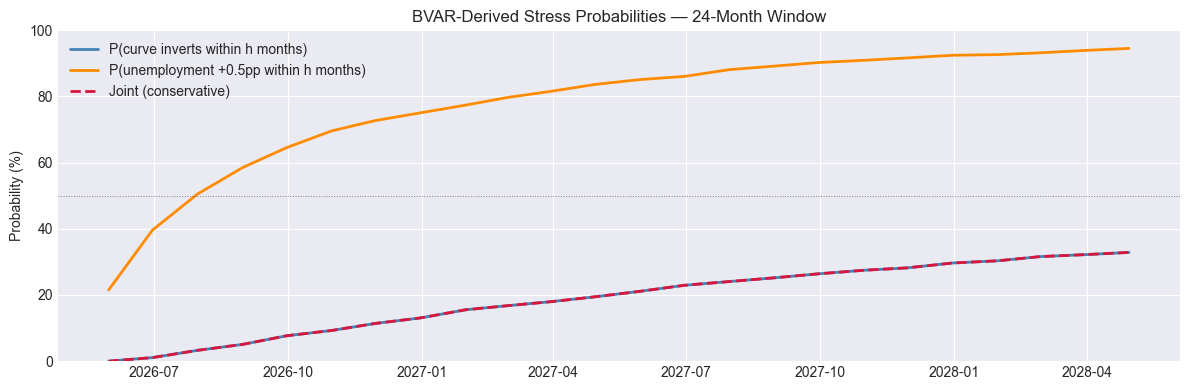

Stress probability summary:
  + 3mo: P(inversion)=3%  P(unrate rise)=51%  P(joint)=3%
  + 6mo: P(inversion)=9%  P(unrate rise)=70%  P(joint)=9%
  +12mo: P(inversion)=19%  P(unrate rise)=84%  P(joint)=19%
  +18mo: P(inversion)=27%  P(unrate rise)=91%  P(joint)=27%
  +24mo: P(inversion)=33%  P(unrate rise)=95%  P(joint)=33%
Saved → output\bvar.xlsx


In [16]:
# ---------------------------------------------------------------------------
# Derived signal: recession probability from BVAR forecasts
# Simple rule: NBER-style threshold on yield curve inversion + unemployment rise
# Counts fraction of paths where BOTH:
#   (1) 10Y-2Y spread < 0 (inverted curve) at some horizon
#   (2) Unemployment rises > 0.5pp from current level
# This is NOT a formal recession model — it is a heuristic based on Sahm rule
# ---------------------------------------------------------------------------
spread_idx = list(SERIES_MAP.keys()).index('t10y2y')
unrate_idx = list(SERIES_MAP.keys()).index('unrate')

current_unrate = df_tr['unrate'].iloc[-1]
current_spread = df_tr['t10y2y'].iloc[-1]

print(f"Current Unemployment Rate:  {current_unrate:.1f}%")
print(f"Current 10Y-2Y Spread:      {current_spread:.2f}%")
print()

# Probability over the forecast horizon
spread_paths = forecast_draws[:, :, spread_idx]    # (S × H_FORE)
unrate_paths = forecast_draws[:, :, unrate_idx]    # (S × H_FORE)

# P(inversion in next h months)
p_inversion = np.array([
    (spread_paths[:, :h].min(axis=1) < 0).mean()
    for h in range(1, H_FORE + 1)
])

# P(unemployment rises 0.5pp+ in next h months)
p_unrise = np.array([
    (unrate_paths[:, :h].max(axis=1) - current_unrate > 0.5).mean()
    for h in range(1, H_FORE + 1)
])

# Joint probability (assuming some correlation — use min as conservative bound)
p_joint = np.minimum(p_inversion, p_unrise)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fore_dates, p_inversion * 100, 'steelblue', lw=2, label='P(curve inverts within h months)')
ax.plot(fore_dates, p_unrise * 100,    'darkorange', lw=2, label='P(unemployment +0.5pp within h months)')
ax.plot(fore_dates, p_joint * 100,     'crimson', lw=2, linestyle='--', label='Joint (conservative)')
ax.set_ylabel("Probability (%)")
ax.set_ylim(0, 100)
ax.set_title("BVAR-Derived Stress Probabilities — 24-Month Window")
ax.legend()
ax.axhline(50, color='gray', linewidth=0.7, linestyle=':')
plt.tight_layout()
plt.show()

print("Stress probability summary:")
for h in [3, 6, 12, 18, 24]:
    print(f"  +{h:2d}mo: P(inversion)={p_inversion[h-1]*100:.0f}%  "
          f"P(unrate rise)={p_unrise[h-1]*100:.0f}%  "
          f"P(joint)={p_joint[h-1]*100:.0f}%")

_stress_df = pd.DataFrame({
    "date":            fore_dates,
    "p_inversion_%":   (p_inversion * 100).round(1),
    "p_unrate_rise_%": (p_unrise    * 100).round(1),
    "p_joint_%":       (p_joint     * 100).round(1),
})
_wb.write("Stress Probabilities", _stress_df)

# ───────────────────────────────────────────────────────────────────────────
# Additional exports
# ───────────────────────────────────────────────────────────────────────────

# OLS Sigma (residual covariance)
_sigma_ols_df = pd.DataFrame(Sigma_ols.round(8), index=short_names, columns=short_names)
_sigma_ols_df.index.name = "variable"
_wb.write("OLS Sigma", _sigma_ols_df.reset_index())

# All lag coefficient matrices (A1-A4) from posterior mean
for _l in range(1, P + 1):
    _Al_post = pd.DataFrame(
        extract_lag(B_post, _l, N).round(6),
        index=short_names, columns=short_names
    )
    _Al_post.index.name = "equation"
    _wb.write(f"A{_l} BVAR Posterior", _Al_post.reset_index())

# Posterior uncertainty for all equations
for _i_eq, _eq_name in enumerate(short_names):
    _A1_eq_draws = B_draws[:, 1:1+N, _i_eq]
    _ci_eq = pd.DataFrame({
        "Mean":  _A1_eq_draws.mean(0),
        "Std":   _A1_eq_draws.std(0),
        "p5":    np.percentile(_A1_eq_draws,  5, axis=0),
        "p16":   np.percentile(_A1_eq_draws, 16, axis=0),
        "p84":   np.percentile(_A1_eq_draws, 84, axis=0),
        "p95":   np.percentile(_A1_eq_draws, 95, axis=0),
    }, index=short_names)
    _ci_eq.index.name = "predictor"
    _wb.write(f"Post Uncert - {_eq_name} Eq", _ci_eq.reset_index())

# IRF credible intervals for ALL shocks (median + 68%/90% bands)
for _si in range(N):
    _sname = short_names[_si]
    _irf_draws_s = SIRF_draws[:n_stable, :, :, _si]  # (S, H+1, N)
    _irf_rows = []
    for _h in range(H + 1):
        row = {"horizon_months": _h}
        for _vi, _vname in enumerate(short_names):
            vals = _irf_draws_s[:, _h, _vi]
            row[f"{_vname}_mean"]   = round(SIRF_mean[_h, _vi, _si], 6)
            row[f"{_vname}_median"] = round(float(np.median(vals)), 6)
            row[f"{_vname}_p5"]     = round(float(np.percentile(vals,  5)), 6)
            row[f"{_vname}_p16"]    = round(float(np.percentile(vals, 16)), 6)
            row[f"{_vname}_p84"]    = round(float(np.percentile(vals, 84)), 6)
            row[f"{_vname}_p95"]    = round(float(np.percentile(vals, 95)), 6)
        _irf_rows.append(row)
    _wb.write(f"IRF - {_sname} Shock", pd.DataFrame(_irf_rows))

# FEVD full path (all horizons 1-48) as single long-format table
_fevd_long = []
for _h in range(1, H + 1):
    for _vi, _vname in enumerate(short_names):
        for _si, _sname_s in enumerate(short_names):
            _fevd_long.append({
                "horizon_months": _h,
                "variable":       _vname,
                "shock":          _sname_s,
                "FEVD_pct":       round(FEVD[_vi, _si, _h] * 100, 3),
            })
_wb.write("FEVD Full Path", pd.DataFrame(_fevd_long))

_wb.save()
print(f"Saved → {_wb.path}")

---
## Summary: What the BVAR Gives Us

| Output | What it answers |
|--------|----------------|
| **Posterior $\bar{\mathbf{B}}$** | How strongly does each variable predict each other variable, after Bayesian shrinkage? |
| **IRF** | If the Fed unexpectedly raises rates 25bps, what happens to unemployment 12 months later? |
| **FEVD** | How much of inflation's forecast uncertainty is driven by Fed Funds shocks vs. real activity shocks? |
| **Forecast bands** | Where is the 10Y yield likely to be in 12 months? What's the 90% credible interval? |
| **Stress probabilities** | Given today's macro state, what fraction of futures involve curve inversion + unemployment rise? |

### Limitations and Extensions

| Issue | Extension |
|-------|----------|
| Constant coefficients | **TVP-VAR** (time-varying parameters) for regime shifts |
| Gaussian innovations | **BVAR-SV** (stochastic volatility) for fat tails |
| Cholesky identification | **Sign restrictions** or **external instruments** for cleaner structural identification |
| 7-variable system | **FAVAR** (Factor-Augmented VAR) to incorporate 100+ series via PCA factors |
| Minnesota prior | **Horseshoe**, **SSVS**, or **Spike-and-Slab** priors for automatic variable selection |

### Key Math Relationships Recap

$$\underbrace{\text{VAR}(p)}_{ \mathbf{Y} = \mathbf{X}\mathbf{B} + \mathbf{E}} \xrightarrow{\text{Bayes + Minnesota prior}} \underbrace{\text{Posterior}}_{ \bar{\mathbf{B}}, \bar{\mathbf{V}}, \bar{\mathbf{S}}, \bar{\nu}} \xrightarrow{\text{MA}(\infty)\text{ + Cholesky}} \underbrace{\text{SIRF}}_{ \mathbf{\Theta}_h = \mathbf{\Phi}_h \mathbf{P}} \xrightarrow{\text{cumulative}} \underbrace{\text{FEVD}}_{ \text{FEVD}_{ij}(h)}$$